# Peristaltic Pump Cycle Detection Pipeline
## Sinusoidal Fitting with Neighborhood Search

This notebook implements a streamlined pipeline for detecting pump cycles using sinusoidal curve fitting with enhanced neighborhood search. The pipeline:

1. **Fits sinusoidal functions** to flow data to identify theoretical cycle patterns
2. **Uses neighborhood search** within a 6-second window around theoretical minima to find actual cycle boundaries
3. **Extracts cycle statistics** and visualizes results for comprehensive analysis

**Key Features:**
- Sinusoidal fitting with R² quality assessment
- 6-second neighborhood search for precise boundary detection
- Comprehensive cycle statistics and metadata
- Multi-dataset processing for 2, 3, and 4-roller pumps
- Interactive visualization with fitted curves and detected cycles

**Algorithm:** Enhanced sinusoidal method with theoretical minima calculation and local neighborhood search for robust cycle boundary detection.

In [20]:
# ===================================================================
# CONFIGURATION & IMPORTS
# ===================================================================

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

# Configuration parameters
SINUSOIDAL_SEARCH_WINDOW_SEC = 12.0  # Neighborhood search window (key parameter)
MIN_TIME_SEPARATION_SEC = 40.0      # Minimum time between cycle boundaries
MIN_CYCLES_REQUIRED = 1             # Minimum cycles needed for successful detection
MAX_LIQUIDS_TO_ANALYZE = 9          # Number of liquids to process per dataset
TRIM_DURATION_SECONDS = 50          # Seconds to trim from data edges
FIGURE_SIZE = (28, 14)             # Visualization size

# Dataset configuration
DATA_FILES = {
    "2-Roller Pump": "Data/viscosity_sensor_calibration/roller2_dataset.csv",
    "3-Roller Pump": "Data/viscosity_sensor_calibration/roller3_dataset.csv", 
    "4-Roller Pump": "Data/viscosity_sensor_calibration/roller4_dataset.csv"
}

# Liquid metadata for visualization
LIQUIDS_INFO = {
    'CF955_flow_ml_min': {'name': 'CF955', 'viscosity': '1 cP'},
    'F50_flow_ml_min': {'name': 'F50', 'viscosity': '50 cP'},
    'F100_flow_ml_min': {'name': 'F100', 'viscosity': '100 cP'},
    'F200_flow_ml_min': {'name': 'F200', 'viscosity': '200 cP'},
    'F350_flow_ml_min': {'name': 'F350', 'viscosity': '350 cP'},
    'F500_flow_ml_min': {'name': 'F500', 'viscosity': '500 cP'},
    'F1000_flow_ml_min': {'name': 'F1000', 'viscosity': '1000 cP'},
    'F5000_flow_ml_min': {'name': 'F5000', 'viscosity': '5000 cP'},
    'F12500_flow_ml_min': {'name': 'F12500', 'viscosity': '12500 cP'}
}

print("🔧 CONFIGURATION LOADED")
print(f"   Sinusoidal search window: {SINUSOIDAL_SEARCH_WINDOW_SEC}s")
print(f"   Time separation: {MIN_TIME_SEPARATION_SEC}s")
print(f"   Processing {len(DATA_FILES)} datasets with {MAX_LIQUIDS_TO_ANALYZE} liquids each")
print("✅ Ready to process pump cycle data")

🔧 CONFIGURATION LOADED
   Sinusoidal search window: 12.0s
   Time separation: 40.0s
   Processing 3 datasets with 9 liquids each
✅ Ready to process pump cycle data


In [21]:
# ===================================================================
# DATA LOADING & PREPROCESSING
# ===================================================================

def load_and_preprocess_data(file_path, dataset_name, trim_seconds=TRIM_DURATION_SECONDS):
    """Load and preprocess pump data with adaptive trimming"""
    try:
        df = pd.read_csv(file_path)
        
        # Adaptive trimming for edge effects
        time_data = df['time_s'].values
        valid_mask = ~np.isnan(time_data)
        
        if np.sum(valid_mask) < 10:
            print(f"   ❌ Insufficient data in {dataset_name}")
            return df
        
        valid_time = time_data[valid_mask]
        time_start, time_end = np.min(valid_time), np.max(valid_time)
        total_duration = time_end - time_start
        
        # Adaptive trimming
        if total_duration <= 2 * trim_seconds + 60:
            actual_trim = max(5, (total_duration - 60) // 2)
        else:
            actual_trim = trim_seconds
        
        # Apply trimming
        trim_mask = (time_data >= time_start + actual_trim) & (time_data <= time_end - actual_trim)
        df_trimmed = df[trim_mask].reset_index(drop=True)
        
        print(f"📊 {dataset_name}: {len(df)} → {len(df_trimmed)} points, trimmed {actual_trim:.0f}s")
        return df_trimmed
        
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {e}")
        return pd.DataFrame()

# Load all datasets
datasets = {}
for name, file_path in DATA_FILES.items():
    datasets[name] = load_and_preprocess_data(file_path, name)

print(f"✅ Loaded {len(datasets)} datasets successfully")

📊 2-Roller Pump: 2907 → 2707 points, trimmed 50s
📊 3-Roller Pump: 2623 → 2423 points, trimmed 50s
📊 4-Roller Pump: 2495 → 2295 points, trimmed 50s
✅ Loaded 3 datasets successfully


In [22]:
# ===================================================================
# SINUSOIDAL CYCLE DETECTION FUNCTION
# ===================================================================

def detect_cycles_sinusoidal(time, flow, search_window_sec=SINUSOIDAL_SEARCH_WINDOW_SEC, min_separation_sec=MIN_TIME_SEPARATION_SEC):
    """
    Enhanced sinusoidal cycle detection with neighborhood search
    
    Algorithm:
    1. Fit sinusoidal function: f(t) = A*sin(ωt + φ) + C
    2. Calculate theoretical minima from fitted function
    3. Search for actual minima within neighborhood windows around theoretical points
    4. Create cycles from consecutive refined boundaries
    5. Apply Min-Max normalization to scale both time and flow to range [0, 1] for each cycle
    
    Returns: cycles list with comprehensive metadata and Min-Max normalized time and flow
    """
    # Data validation and cleaning
    valid_mask = ~np.isnan(flow) & ~np.isnan(time)
    if np.sum(valid_mask) < 10:
        return []
    
    valid_time = time[valid_mask]
    valid_flow = flow[valid_mask]
    sort_indices = np.argsort(valid_time)
    valid_time = valid_time[sort_indices]
    valid_flow = valid_flow[sort_indices]
    
    # 1. Sinusoidal fitting
    def sinusoidal_function(t, A, omega, phi, C):
        return A * np.sin(omega * t + phi) + C
    
    try:
        # Parameter initialization
        C_init = np.mean(valid_flow)
        A_init = (np.max(valid_flow) - np.min(valid_flow)) / 2
        
        # FFT-based frequency estimation
        detrended_flow = valid_flow - C_init
        dt = np.mean(np.diff(valid_time))
        freqs = np.fft.fftfreq(len(detrended_flow), dt)
        fft_values = np.abs(np.fft.fft(detrended_flow))
        
        positive_freqs = freqs[1:len(freqs)//2]
        positive_fft = fft_values[1:len(fft_values)//2]
        
        if len(positive_freqs) > 0:
            dominant_freq = positive_freqs[np.argmax(positive_fft)]
            omega_init = 2 * np.pi * dominant_freq
        else:
            time_range = np.max(valid_time) - np.min(valid_time)
            omega_init = 2 * np.pi * 3 / time_range  # Assume ~3 cycles
        
        # Curve fitting with bounds
        bounds = ([-np.inf, 0.01, -2*np.pi, -np.inf], [np.inf, 10.0, 2*np.pi, np.inf])
        fitted_params, _ = curve_fit(
            sinusoidal_function, valid_time, valid_flow,
            p0=[A_init, omega_init, 0, C_init], bounds=bounds, maxfev=5000
        )
        
        A_fit, omega_fit, phi_fit, C_fit = fitted_params
        fitted_curve = sinusoidal_function(valid_time, *fitted_params)
        
        # Calculate fit quality
        ss_res = np.sum((valid_flow - fitted_curve) ** 2)
        ss_tot = np.sum((valid_flow - np.mean(valid_flow)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        fitted_period = 2 * np.pi / omega_fit
        
        print(f"   🌊 Fitted sinusoid: Period={fitted_period:.1f}s, R²={r_squared:.3f}")
        
    except Exception as e:
        print(f"   ❌ Sinusoidal fitting failed: {e}")
        return []
    
    # 2. Calculate theoretical minima
    if A_fit > 0:
        base_phase = -np.pi/2 - phi_fit
    else:
        base_phase = np.pi/2 - phi_fit
    
    time_start, time_end = np.min(valid_time), np.max(valid_time)
    theoretical_minima = []
    
    k = -10  # Search range for theoretical points
    while k <= 10:
        t_min = (base_phase + 2 * np.pi * k) / omega_fit
        if time_start - fitted_period <= t_min <= time_end + fitted_period:
            theoretical_minima.append(t_min)
        k += 1
    
    theoretical_minima = sorted(theoretical_minima)
    
    # 3. Neighborhood search for actual minima
    actual_minima = []
    for theoretical_time in theoretical_minima:
        window_start = theoretical_time - search_window_sec / 2
        window_end = theoretical_time + search_window_sec / 2
        
        window_mask = (valid_time >= window_start) & (valid_time <= window_end)
        window_indices = np.where(window_mask)[0]
        
        if len(window_indices) == 0:
            continue
        
        # Find actual minimum in window
        window_flow = valid_flow[window_indices]
        min_idx = np.argmin(window_flow)
        actual_idx = window_indices[min_idx]
        
        actual_minima.append({
            'theoretical_time': theoretical_time,
            'actual_time': valid_time[actual_idx],
            'actual_flow': valid_flow[actual_idx],
            'offset': valid_time[actual_idx] - theoretical_time,
            'data_index': actual_idx
        })
    
    # 4. Filter and create cycles
    filtered_minima = []
    for min_info in actual_minima:
        if time_start <= min_info['actual_time'] <= time_end:
            # Check separation constraint
            too_close = False
            for existing in filtered_minima:
                if abs(min_info['actual_time'] - existing['actual_time']) < min_separation_sec:
                    too_close = True
                    break
            
            if not too_close:
                filtered_minima.append(min_info)
    
    filtered_minima = sorted(filtered_minima, key=lambda x: x['actual_time'])
    
    # 5. Generate cycle objects with normalized time
    cycles = []
    for i in range(len(filtered_minima) - 1):
        start_min = filtered_minima[i]
        end_min = filtered_minima[i + 1]
        
        start_time, end_time = start_min['actual_time'], end_min['actual_time']
        cycle_mask = (valid_time >= start_time) & (valid_time <= end_time)
        cycle_time_data = valid_time[cycle_mask]
        cycle_flow_data = valid_flow[cycle_mask]
        
        if len(cycle_time_data) < 3:
            continue
        
        # Apply Min-Max normalization to scale time to range [0, 1]
        time_min = np.min(cycle_time_data)
        time_max = np.max(cycle_time_data)
        if time_max > time_min:  # Avoid division by zero
            normalized_cycle_time = (cycle_time_data - time_min) / (time_max - time_min)
        else:
            normalized_cycle_time = np.zeros_like(cycle_time_data)  # All zeros if no time variation
        
        # Apply Min-Max normalization to scale flow to range [0, 1]
        flow_min = np.min(cycle_flow_data)
        flow_max = np.max(cycle_flow_data)
        if flow_max > flow_min:  # Avoid division by zero
            normalized_cycle_flow = (cycle_flow_data - flow_min) / (flow_max - flow_min)
        else:
            normalized_cycle_flow = np.zeros_like(cycle_flow_data)  # All zeros if no flow variation
        
        # Find peak in cycle
        peak_idx = np.argmax(cycle_flow_data)
        
        # Comprehensive cycle metadata with normalized time and flow
        cycle_info = {
            'cycle_number': len(cycles) + 1,
            'start_time': start_time,  # Keep original absolute time for reference
            'peak_time': cycle_time_data[peak_idx],  # Keep original absolute peak time
            'end_time': end_time,  # Keep original absolute time for reference
            'duration': end_time - start_time,
            'amplitude': cycle_flow_data[peak_idx] - min(start_min['actual_flow'], end_min['actual_flow']),
            'peak_flow': cycle_flow_data[peak_idx],
            'start_flow': start_min['actual_flow'],
            'end_flow': end_min['actual_flow'],
            'cycle_time': normalized_cycle_time.copy(),  # NORMALIZED time [0, 1]
            'cycle_flow': normalized_cycle_flow.copy(),  # NORMALIZED flow [0, 1]
            'original_cycle_time': cycle_time_data.copy(),  # Keep original for reference
            'original_cycle_flow': cycle_flow_data.copy(),  # Keep original for reference
            'data_points': len(cycle_time_data),
            'fitted_period': fitted_period,
            'fit_r_squared': r_squared,
            'start_offset': start_min['offset'],
            'end_offset': end_min['offset'],
            'search_window_sec': search_window_sec,
            'detection_method': 'Sinusoidal Fit + Neighborhood Search',
            'normalized_peak_time': normalized_cycle_time[peak_idx],  # Peak time in normalized scale
            'normalized_peak_flow': normalized_cycle_flow[peak_idx],  # Peak flow in normalized scale
            'flow_range': (flow_min, flow_max),  # Original flow range for denormalization
            'time_range': (time_min, time_max)   # Original time range for denormalization
        }
        cycles.append(cycle_info)
    
    print(f"   ✅ Detected {len(cycles)} cycles from {len(filtered_minima)} boundaries (with Min-Max normalized time & flow)")
    return cycles

print("✅ SINUSOIDAL DETECTION FUNCTION READY")
print(f"   🔍 Enhanced algorithm with {SINUSOIDAL_SEARCH_WINDOW_SEC}s neighborhood search")
print(f"   ⏱️  Each cycle now has Min-Max normalized time and flow scaled to [0, 1]")

✅ SINUSOIDAL DETECTION FUNCTION READY
   🔍 Enhanced algorithm with 12.0s neighborhood search
   ⏱️  Each cycle now has Min-Max normalized time and flow scaled to [0, 1]


In [23]:
# ===================================================================
# CYCLE PHASE DETECTION FUNCTION
# ===================================================================

def detect_cycle_phases(cycle_data, phase1_percent=15, phase4_percent=10):
    """
    Detect 4 phases within a single cycle based on time percentages and median
    
    Parameters:
    - cycle_data: Single cycle from detect_cycles_sinusoidal result
    - phase1_percent: Percentage for phase 1 (default 20%)
    - phase4_percent: Percentage for phase 4 (default 30%) 
    
    Returns:
    - Dictionary with phase information including start/end indices and timing
    """
    try:
        cycle_time = cycle_data['cycle_time']
        cycle_flow = cycle_data['cycle_flow']
        
        if len(cycle_time) < 4:
            return None
            
        # Calculate time-based boundaries
        total_duration = cycle_time[-1] - cycle_time[0]
        phase1_duration = total_duration * (phase1_percent / 100)
        phase4_duration = total_duration * (phase4_percent / 100)
        
        # Find indices for phase boundaries
        phase1_end_time = cycle_time[0] + phase1_duration
        phase4_start_time = cycle_time[-1] - phase4_duration
        
        # Find closest indices
        phase1_end_idx = np.argmin(np.abs(cycle_time - phase1_end_time))
        phase4_start_idx = np.argmin(np.abs(cycle_time - phase4_start_time))
        
        # Find median index for phase 3 start
        median_idx = len(cycle_time) // 2
        
        # Ensure proper ordering: phase1_end < median < phase4_start
        if phase1_end_idx >= median_idx:
            phase1_end_idx = max(0, median_idx - 1)
        if phase4_start_idx <= median_idx:
            phase4_start_idx = min(len(cycle_time) - 1, median_idx + 1)
        
        # Define phase boundaries
        phases = {
            'phase1_start': 0,
            'phase1_end': phase1_end_idx,
            'phase2_start': phase1_end_idx + 1,
            'phase2_end': median_idx - 1,
            'phase3_start': median_idx,
            'phase3_end': phase4_start_idx - 1,
            'phase4_start': phase4_start_idx,
            'phase4_end': len(cycle_time) - 1,
            'peak_idx': np.argmax(cycle_flow),
            'total_points': len(cycle_time),
            'phase1_percent': phase1_percent,
            'phase4_percent': phase4_percent
        }
        
        # Calculate phase durations and statistics
        for phase_num in range(1, 5):
            start_key = f'phase{phase_num}_start'
            end_key = f'phase{phase_num}_end'
            
            if phases[end_key] >= phases[start_key]:
                start_idx = phases[start_key]
                end_idx = phases[end_key]
                
                phase_time_data = cycle_time[start_idx:end_idx+1]
                phase_flow_data = cycle_flow[start_idx:end_idx+1]
                
                phases[f'phase{phase_num}_duration'] = phase_time_data[-1] - phase_time_data[0] if len(phase_time_data) > 1 else 0
                phases[f'phase{phase_num}_points'] = len(phase_time_data)
                phases[f'phase{phase_num}_avg_flow'] = np.mean(phase_flow_data) if len(phase_flow_data) > 0 else 0
                phases[f'phase{phase_num}_max_flow'] = np.max(phase_flow_data) if len(phase_flow_data) > 0 else 0
                phases[f'phase{phase_num}_min_flow'] = np.min(phase_flow_data) if len(phase_flow_data) > 0 else 0
            else:
                # Handle edge case where phase boundaries don't make sense
                phases[f'phase{phase_num}_duration'] = 0
                phases[f'phase{phase_num}_points'] = 0
                phases[f'phase{phase_num}_avg_flow'] = 0
                phases[f'phase{phase_num}_max_flow'] = 0
                phases[f'phase{phase_num}_min_flow'] = 0
        
        return phases
        
    except Exception as e:
        print(f"   ⚠️  Phase detection failed: {e}")
        return None

print("✅ CYCLE PHASE DETECTION FUNCTION READY")
print(f"   📊 Configurable phase percentages: Phase 1 (default 20%), Phase 4 (default 30%)")
print(f"   🎯 Phase 3 starts from median, Phase 2 fills the gap")

✅ CYCLE PHASE DETECTION FUNCTION READY
   📊 Configurable phase percentages: Phase 1 (default 20%), Phase 4 (default 30%)
   🎯 Phase 3 starts from median, Phase 2 fills the gap


In [24]:
# ===================================================================
# SAVITZKY-GOLAY SMOOTHING FUNCTION
# ===================================================================

def Savitzky_Golay_filter(pipeline_results, window_length=51, polyorder=3):
    """
    Apply Savitzky-Golay filter to smooth the flow data in all detected cycles
    
    Parameters:
    - pipeline_results: The results dictionary from run_complete_pipeline
    - window_length: Length of the filter window (must be odd and > polyorder)
    - polyorder: Order of the polynomial used to fit the samples
    
    Returns:
    - Modified pipeline_results with smoothed cycle data
    """
    print(f"\n🌊 APPLYING SAVITZKY-GOLAY SMOOTHING (window={window_length}, poly={polyorder})")
    print("=" * 60)
    
    smoothed_results = pipeline_results.copy()
    total_cycles_smoothed = 0
    
    for dataset_name, dataset_data in smoothed_results['datasets'].items():
        print(f"\n📊 Processing: {dataset_name}")
        
        dataset_cycles_smoothed = 0
        
        for liquid_name, liquid_result in dataset_data['liquid_results'].items():
            if liquid_result['successful'] and liquid_result['cycles']:
                liquid_cycles_smoothed = 0
                
                for i, cycle in enumerate(liquid_result['cycles']):
                    if 'cycle_flow' in cycle and len(cycle['cycle_flow']) > window_length:
                        try:
                            # Apply Savitzky-Golay filter to the cycle flow data
                            original_flow = cycle['cycle_flow']
                            smoothed_flow = savgol_filter(original_flow, window_length, polyorder)
                            
                            # Update the cycle with smoothed data
                            cycle['cycle_flow_original'] = original_flow.copy()  # Keep original
                            cycle['cycle_flow'] = smoothed_flow
                            cycle['smoothed'] = True
                            cycle['smooth_params'] = {'window_length': window_length, 'polyorder': polyorder}
                            
                            liquid_cycles_smoothed += 1
                            total_cycles_smoothed += 1
                            
                        except Exception as e:
                            print(f"      ⚠️  Failed to smooth cycle {i+1} for {liquid_name}: {str(e)}")
                            cycle['smoothed'] = False
                    else:
                        # Cycle too short for smoothing or missing flow data
                        cycle['smoothed'] = False
                        if 'cycle_flow' in cycle:
                            cycle['cycle_flow_original'] = cycle['cycle_flow'].copy()
                
                dataset_cycles_smoothed += liquid_cycles_smoothed
                if liquid_cycles_smoothed > 0:
                    print(f"   🎯 {liquid_name}: {liquid_cycles_smoothed}/{len(liquid_result['cycles'])} cycles smoothed")
        
        if dataset_cycles_smoothed > 0:
            print(f"   📈 Dataset total: {dataset_cycles_smoothed} cycles smoothed")
    
    # Add smoothing info to results summary
    smoothed_results['smoothing_applied'] = {
        'total_cycles_smoothed': total_cycles_smoothed,
        'window_length': window_length,
        'polyorder': polyorder,
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    print(f"\n🌊 SMOOTHING SUMMARY:")
    print(f"   ✅ Total cycles smoothed: {total_cycles_smoothed}")
    print(f"   📊 Filter parameters: window={window_length}, polynomial_order={polyorder}")
    print(f"   ✅ SMOOTHING COMPLETE!")
    
    return smoothed_results

# ===================================================================
# MAIN PIPELINE EXECUTION
# ===================================================================

def run_complete_pipeline(datasets_dict):
    """Execute the complete sinusoidal cycle detection pipeline"""
    results = {
        'parameters': {
            'search_window_sec': SINUSOIDAL_SEARCH_WINDOW_SEC,
            'min_separation_sec': MIN_TIME_SEPARATION_SEC,
            'method': 'Enhanced Sinusoidal + Neighborhood Search'
        },
        'datasets': {},
        'summary': {'total_successful': 0, 'total_failed': 0, 'total_cycles': 0}
    }
    
    print("🚀 EXECUTING SINUSOIDAL CYCLE DETECTION PIPELINE")
    print("=" * 60)
    
    for dataset_name, df in datasets_dict.items():
        print(f"\n🔍 Processing: {dataset_name}")
        
        dataset_results = {
            'liquid_results': {},
            'successful_liquids': 0,
            'failed_liquids': 0,
            'total_cycles_detected': 0
        }
        
        # Process each liquid column
        liquid_columns = [col for col in df.columns if col.endswith('_flow_ml_min')]
        
        for liquid_col in liquid_columns[:MAX_LIQUIDS_TO_ANALYZE]:
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            print(f"   📊 {liquid_name}...", end=' ')
            
            time_data = df['time_s'].values
            flow_data = df[liquid_col].values
            
            # Data validation
            valid_mask = ~np.isnan(time_data) & ~np.isnan(flow_data)
            if np.sum(valid_mask) < 10:
                print("❌ Insufficient data")
                dataset_results['liquid_results'][liquid_name] = {
                    'cycles': [], 'num_cycles': 0, 'successful': False, 'error': 'Insufficient data'
                }
                dataset_results['failed_liquids'] += 1
                continue
            
            # Run cycle detection
            cycles = detect_cycles_sinusoidal(time_data, flow_data)
            
            # Apply phase detection to each detected cycle
            cycles_with_phases = []
            for cycle in cycles:
                # Add phase information to each cycle
                phases = detect_cycle_phases(cycle)
                if phases:
                    cycle['phases'] = phases
                else:
                    cycle['phases'] = None
                cycles_with_phases.append(cycle)
            
            # Calculate statistics
            if cycles_with_phases:
                durations = [c['duration'] for c in cycles_with_phases]
                amplitudes = [c['amplitude'] for c in cycles_with_phases]
                r_squared_values = [c['fit_r_squared'] for c in cycles_with_phases]
                
                # Count cycles with successful phase detection
                cycles_with_phases_count = sum(1 for c in cycles_with_phases if c['phases'] is not None)
                
                liquid_result = {
                    'cycles': cycles_with_phases,
                    'num_cycles': len(cycles_with_phases),
                    'cycles_with_phases': cycles_with_phases_count,
                    'successful': len(cycles_with_phases) >= MIN_CYCLES_REQUIRED,
                    'avg_duration': np.mean(durations),
                    'std_duration': np.std(durations),
                    'avg_amplitude': np.mean(amplitudes),
                    'fitted_period': cycles_with_phases[0]['fitted_period'],
                    'avg_fit_r_squared': np.mean(r_squared_values),
                    'flow_range': (np.min(flow_data[valid_mask]), np.max(flow_data[valid_mask])),
                    'time_range': (np.min(time_data[valid_mask]), np.max(time_data[valid_mask]))
                }
                
                print(f"✅ {len(cycles_with_phases)} cycles ({cycles_with_phases_count} with phases, {np.mean(durations):.0f}s avg)")
                
                if len(cycles_with_phases) >= MIN_CYCLES_REQUIRED:
                    dataset_results['successful_liquids'] += 1
                    dataset_results['total_cycles_detected'] += len(cycles_with_phases)
                    results['summary']['total_cycles'] += len(cycles_with_phases)
                else:
                    dataset_results['failed_liquids'] += 1
            else:
                print("❌ No cycles")
                liquid_result = {
                    'cycles': [], 'num_cycles': 0, 'cycles_with_phases': 0, 'successful': False,
                    'flow_range': (np.min(flow_data[valid_mask]), np.max(flow_data[valid_mask])),
                    'time_range': (np.min(time_data[valid_mask]), np.max(time_data[valid_mask]))
                }
                dataset_results['failed_liquids'] += 1
            
            dataset_results['liquid_results'][liquid_name] = liquid_result
        
        results['datasets'][dataset_name] = dataset_results
        
        # Dataset summary
        total_liquids = dataset_results['successful_liquids'] + dataset_results['failed_liquids']
        success_rate = dataset_results['successful_liquids'] / total_liquids * 100 if total_liquids > 0 else 0
        print(f"   📈 Success: {dataset_results['successful_liquids']}/{total_liquids} ({success_rate:.1f}%)")
        print(f"   🎯 Total cycles: {dataset_results['total_cycles_detected']}")
    
    # Overall summary
    results['summary']['total_successful'] = sum(d['successful_liquids'] for d in results['datasets'].values())
    results['summary']['total_failed'] = sum(d['failed_liquids'] for d in results['datasets'].values())
    
    total_combinations = results['summary']['total_successful'] + results['summary']['total_failed']
    overall_success_rate = results['summary']['total_successful'] / total_combinations * 100 if total_combinations > 0 else 0
    
    print(f"\n📊 PIPELINE SUMMARY:")
    print(f"   ✅ Overall success: {results['summary']['total_successful']}/{total_combinations} ({overall_success_rate:.1f}%)")
    print(f"   🎯 Total cycles detected: {results['summary']['total_cycles']}")
    
    # Phase detection summary
    total_cycles = results['summary']['total_cycles']
    total_cycles_with_phases = 0
    for dataset_results in results['datasets'].values():
        for liquid_result in dataset_results['liquid_results'].values():
            if 'cycles_with_phases' in liquid_result:
                total_cycles_with_phases += liquid_result['cycles_with_phases']
    
    if total_cycles > 0:
        phase_success_rate = total_cycles_with_phases / total_cycles * 100
        print(f"   🔄 Phase detection: {total_cycles_with_phases}/{total_cycles} cycles ({phase_success_rate:.1f}%)")
    
    # Apply Savitzky-Golay smoothing to the results
    results = Savitzky_Golay_filter(results)
    
    return results

# Execute the pipeline
pipeline_results = run_complete_pipeline(datasets)

🚀 EXECUTING SINUSOIDAL CYCLE DETECTION PIPELINE

🔍 Processing: 2-Roller Pump
   📊 CF955...    🌊 Fitted sinusoid: Period=161.6s, R²=0.373
   ✅ Detected 5 cycles from 6 boundaries (with Min-Max normalized time & flow)
✅ 5 cycles (5 with phases, 161s avg)
   📊 F50...    🌊 Fitted sinusoid: Period=158.2s, R²=0.419
   ✅ Detected 4 cycles from 5 boundaries (with Min-Max normalized time & flow)
✅ 4 cycles (4 with phases, 158s avg)
   📊 F100...    🌊 Fitted sinusoid: Period=161.3s, R²=0.420
   ✅ Detected 8 cycles from 9 boundaries (with Min-Max normalized time & flow)
✅ 8 cycles (8 with phases, 162s avg)
   📊 F200...    🌊 Fitted sinusoid: Period=161.7s, R²=0.417
   ✅ Detected 6 cycles from 7 boundaries (with Min-Max normalized time & flow)
✅ 6 cycles (6 with phases, 163s avg)
   📊 F350...    🌊 Fitted sinusoid: Period=80.5s, R²=0.433
   ✅ Detected 9 cycles from 10 boundaries (with Min-Max normalized time & flow)
✅ 9 cycles (9 with phases, 80s avg)
   📊 F500...    🌊 Fitted sinusoid: Period=80.0s, 

🎨 Creating comprehensive results visualization...


C:\Users\mrast\AppData\Local\Temp\ipykernel_31696\2224391768.py:144: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\mrast\.conda\envs\sdl_pmp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


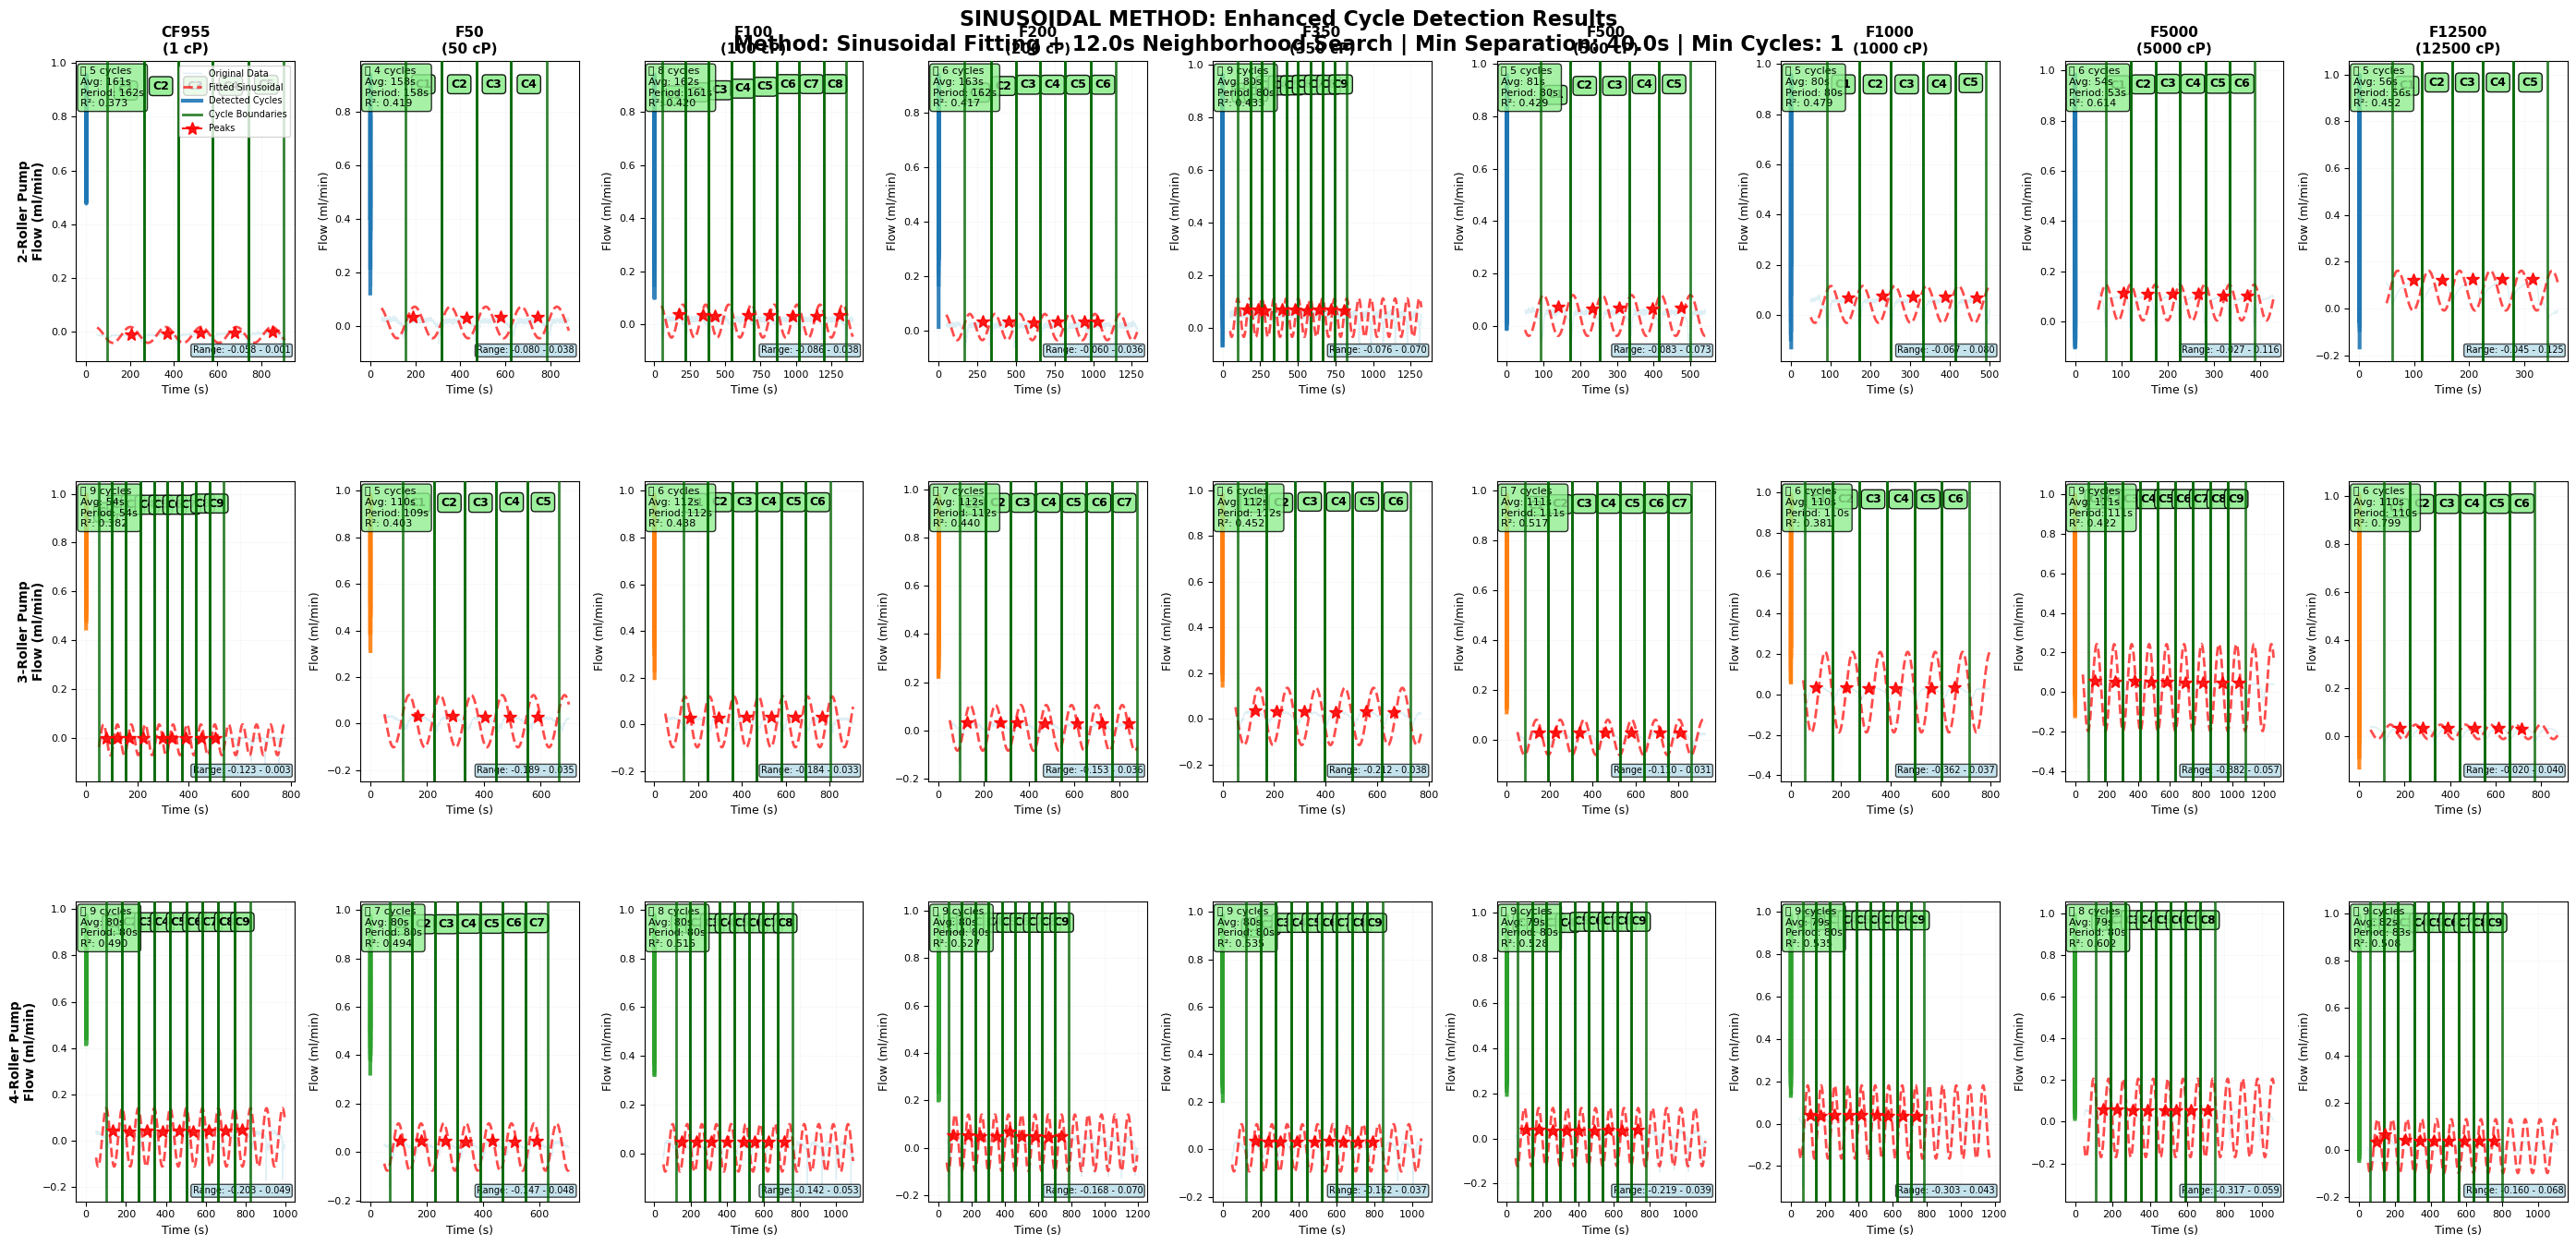

✅ VISUALIZATION COMPLETE
🎯 Displayed results for 3 datasets across 9 liquid types


In [25]:
# ===================================================================
# COMPREHENSIVE VISUALIZATION
# ===================================================================

def create_results_visualization(results, datasets_dict):
    """Create comprehensive visualization of cycle detection results"""
    dataset_names = list(datasets_dict.keys())
    liquid_names = list(LIQUIDS_INFO.keys())[:MAX_LIQUIDS_TO_ANALYZE]
    
    # Create subplot grid
    fig, axes = plt.subplots(len(dataset_names), len(liquid_names), figsize=FIGURE_SIZE)
    if len(dataset_names) == 1:
        axes = axes.reshape(1, -1)
    
    # Main title
    title = (f'SINUSOIDAL METHOD: Enhanced Cycle Detection Results\n'
             f'Method: Sinusoidal Fitting + {SINUSOIDAL_SEARCH_WINDOW_SEC}s Neighborhood Search | '
             f'Min Separation: {MIN_TIME_SEPARATION_SEC}s | Min Cycles: {MIN_CYCLES_REQUIRED}')
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.96)
    
    # Colors for each pump configuration
    pump_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # Plot each combination
    for dataset_idx, (dataset_name, df) in enumerate(datasets_dict.items()):
        dataset_results = results['datasets'][dataset_name]
        pump_color = pump_colors[dataset_idx]
        
        for liquid_idx, liquid_col in enumerate(liquid_names):
            ax = axes[dataset_idx, liquid_idx]
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            liquid_info = LIQUIDS_INFO[liquid_col]
            
            # Get data
            time_data = df['time_s'].values
            flow_data = df[liquid_col].values
            
            # Plot original data
            ax.plot(time_data, flow_data, alpha=0.4, linewidth=1, color='lightblue', 
                   label='Original Data', zorder=1)
            
            # Process results if available
            if liquid_name in dataset_results['liquid_results']:
                liquid_result = dataset_results['liquid_results'][liquid_name]
                cycles = liquid_result['cycles']
                
                if cycles and liquid_result['successful']:
                    # Plot fitted sinusoidal curve
                    valid_mask = ~np.isnan(flow_data) & ~np.isnan(time_data)
                    if np.sum(valid_mask) > 0:
                        valid_time = time_data[valid_mask]
                        sort_indices = np.argsort(valid_time)
                        valid_time_sorted = valid_time[sort_indices]
                        
                        # Generate fitted curve using parameters from first cycle
                        cycle = cycles[0]
                        fitted_period = cycle['fitted_period']
                        
                        # Simplified fitted curve for visualization
                        C_fit = np.mean(flow_data[valid_mask])
                        A_fit = (np.max(flow_data[valid_mask]) - np.min(flow_data[valid_mask])) / 2
                        omega_fit = 2 * np.pi / fitted_period
                        phi_fit = 0  # Simplified for visualization
                        
                        fitted_values = A_fit * np.sin(omega_fit * valid_time_sorted + phi_fit) + C_fit
                        ax.plot(valid_time_sorted, fitted_values, color='red', linewidth=2, 
                               alpha=0.7, label='Fitted Sinusoidal', linestyle='--', zorder=2)
                    
                    # Plot detected cycles
                    for cycle_idx, cycle in enumerate(cycles):
                        cycle_time = cycle['cycle_time']
                        cycle_flow = cycle['cycle_flow']
                        
                        # Highlight detected cycle
                        ax.plot(cycle_time, cycle_flow, color=pump_color, linewidth=3, 
                               alpha=0.9, label='Detected Cycles' if cycle_idx == 0 else '', zorder=3)
                        
                        # Mark cycle boundaries
                        ax.axvline(cycle['start_time'], color='darkgreen', alpha=0.8, linestyle='-', 
                                  linewidth=2, label='Cycle Boundaries' if cycle_idx == 0 else '', zorder=4)
                        ax.axvline(cycle['end_time'], color='darkgreen', alpha=0.8, linestyle='-', 
                                  linewidth=2, zorder=4)
                        
                        # Mark peaks
                        ax.plot(cycle['peak_time'], cycle['peak_flow'], marker='*', 
                               color='red', markersize=10, alpha=0.9, zorder=5,
                               label='Peaks' if cycle_idx == 0 else '')
                        
                        # Cycle number annotation
                        mid_time = (cycle['start_time'] + cycle['end_time']) / 2
                        ax.text(mid_time, ax.get_ylim()[1] * 0.90, f'C{cycle_idx+1}', 
                               ha='center', fontsize=9, fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.9))
                    
                    # Success statistics
                    avg_duration = liquid_result.get('avg_duration', 0)
                    fitted_period = liquid_result.get('fitted_period', 0)
                    r_squared = liquid_result.get('avg_fit_r_squared', 0)
                    
                    success_text = (f'✅ {len(cycles)} cycles\n'
                                   f'Avg: {avg_duration:.0f}s\n'
                                   f'Period: {fitted_period:.0f}s\n'
                                   f'R²: {r_squared:.3f}')
                    ax.text(0.02, 0.98, success_text, transform=ax.transAxes, fontsize=8,
                           verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', 
                           facecolor='lightgreen', alpha=0.8))
                
                else:
                    # Failure indicator
                    cycles_found = len(cycles) if cycles else 0
                    fail_text = f'❌ {cycles_found} cycles\n(< {MIN_CYCLES_REQUIRED} required)'
                    
                    ax.text(0.5, 0.5, fail_text, transform=ax.transAxes, ha='center', va='center',
                           fontsize=10, color='red', fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', alpha=0.8))
                
                # Flow range information
                flow_range = liquid_result.get('flow_range', (np.nan, np.nan))
                flow_stats = f'Range: {flow_range[0]:.3f} - {flow_range[1]:.3f}'
                ax.text(0.98, 0.02, flow_stats, transform=ax.transAxes, fontsize=7,
                       verticalalignment='bottom', horizontalalignment='right',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.7))
            
            # Formatting
            ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
            ax.set_xlabel('Time (s)', fontsize=9)
            
            # Titles and labels
            if dataset_idx == 0:
                ax.set_title(f'{liquid_info["name"]}\n({liquid_info["viscosity"]})', 
                           fontsize=11, fontweight='bold')
            
            if liquid_idx == 0:
                ax.set_ylabel(f'{dataset_name}\nFlow (ml/min)', fontsize=10, fontweight='bold')
            else:
                ax.set_ylabel('Flow (ml/min)', fontsize=9)
            
            ax.tick_params(labelsize=8)
            
            # Legend on first subplot
            if dataset_idx == 0 and liquid_idx == 0:
                ax.legend(loc='upper right', fontsize=7, ncol=1)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
    return fig

# Create and display visualization
print("🎨 Creating comprehensive results visualization...")
results_figure = create_results_visualization(pipeline_results, datasets)
plt.show()

print("✅ VISUALIZATION COMPLETE")
print(f"🎯 Displayed results for {len(datasets)} datasets across {MAX_LIQUIDS_TO_ANALYZE} liquid types")

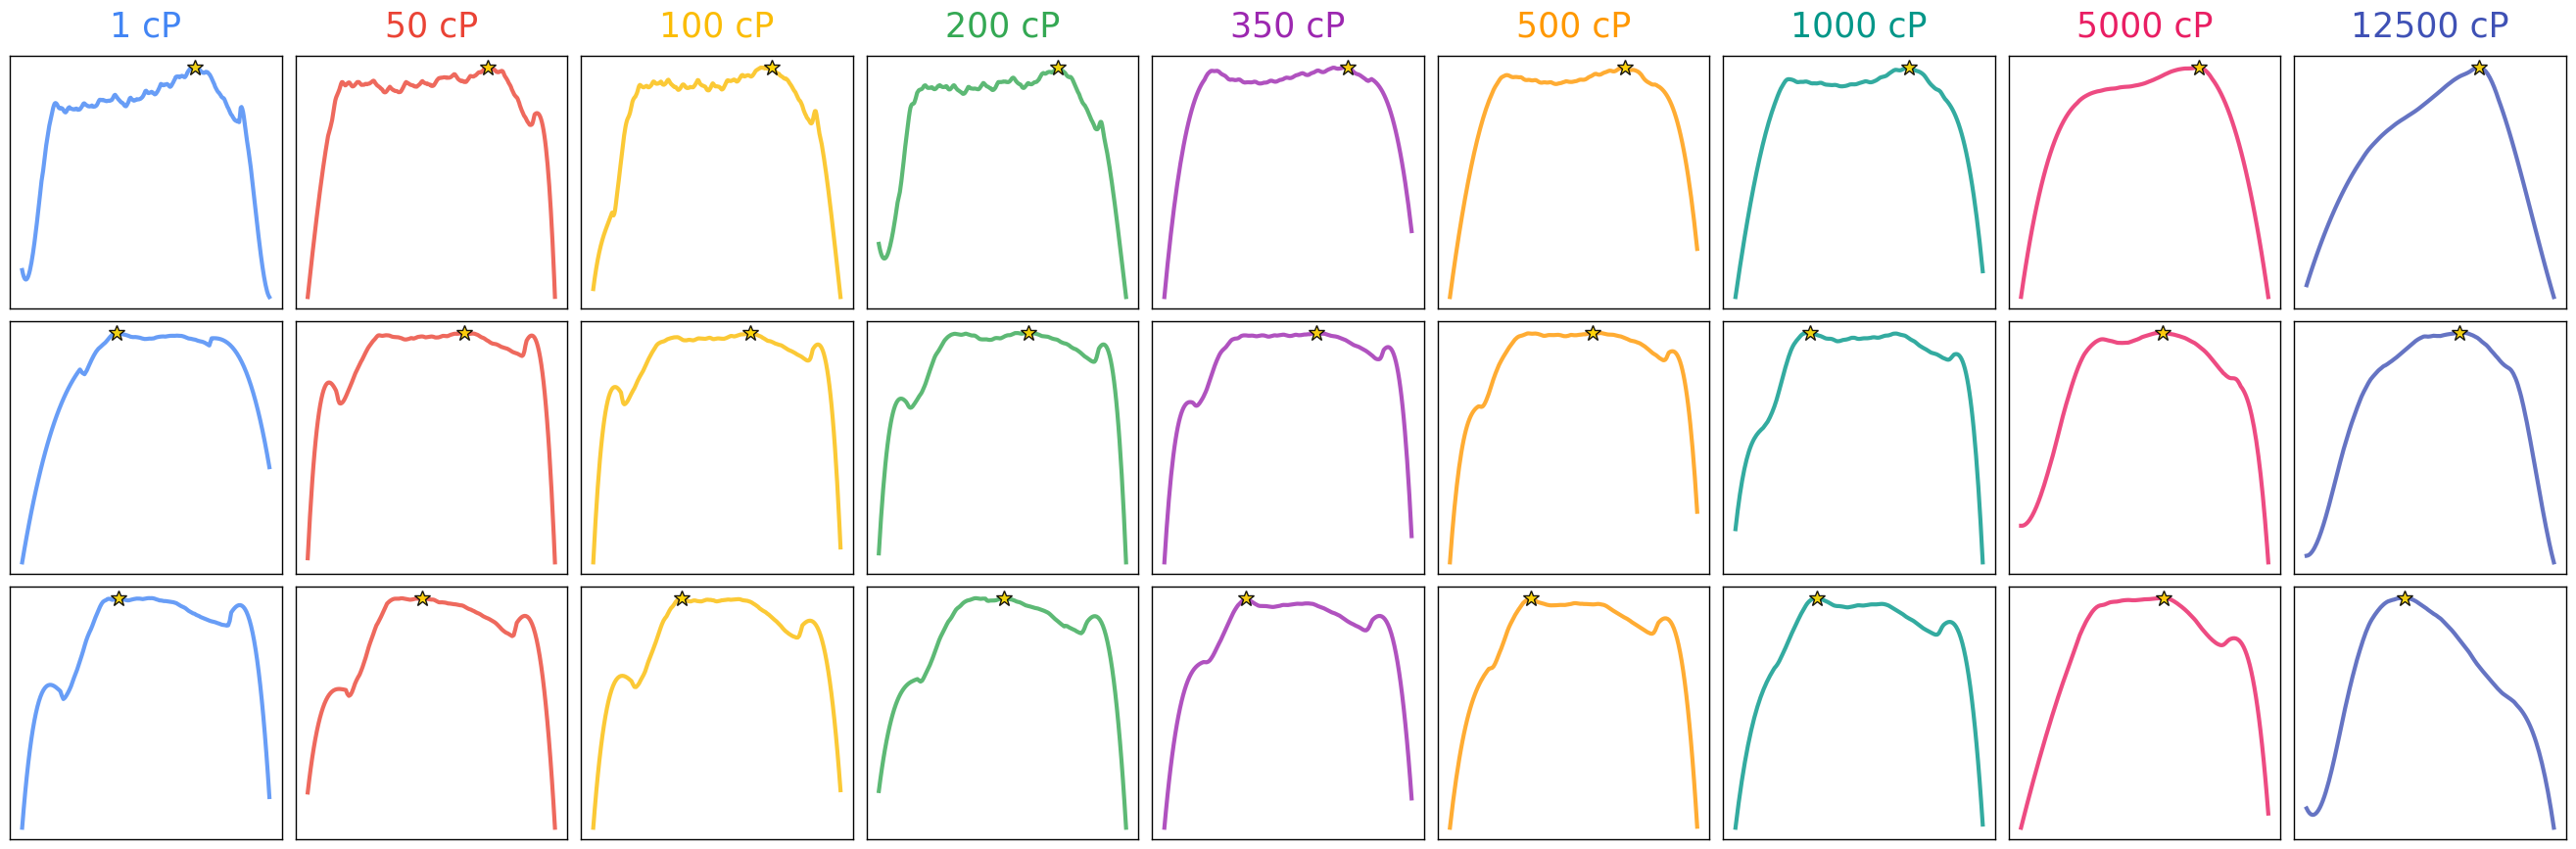

In [26]:
# ===================================================================
# SINGLE CYCLE VISUALIZATION GRID (3x9)
# ===================================================================

def create_single_cycle_grid(results, datasets_dict):
    """Create 3x9 grid showing single representative cycles for each pump-sample combination"""
    
    # Google color palette
    google_colors = {
        'blue': '#4285F4',
        'red': '#EA4335', 
        'yellow': '#FBBC04',
        'green': '#34A853',
        'purple': '#9C27B0',
        'orange': '#FF9800',
        'teal': '#009688',
        'pink': '#E91E63',
        'indigo': '#3F51B5'
    }
    
    dataset_names = list(datasets_dict.keys())  # ['2-Roller Pump', '3-Roller Pump', '4-Roller Pump']
    liquid_names = list(LIQUIDS_INFO.keys())[:MAX_LIQUIDS_TO_ANALYZE]
    color_list = list(google_colors.values())
    
    # Create 3x9 subplot grid with increased height
    fig, axes = plt.subplots(3, 9, figsize=(30, 10))
    
    # Plot each combination
    for dataset_idx, dataset_name in enumerate(dataset_names):
        dataset_results = results['datasets'][dataset_name]
        
        for liquid_idx, liquid_col in enumerate(liquid_names):
            ax = axes[dataset_idx, liquid_idx]
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            liquid_info = LIQUIDS_INFO[liquid_col]
            
            # Get color for this liquid
            color = color_list[liquid_idx % len(color_list)]
            
            # Clear the plot
            ax.clear()
            
            # Process results if available
            if liquid_name in dataset_results['liquid_results']:
                liquid_result = dataset_results['liquid_results'][liquid_name]
                
                if liquid_result['successful'] and liquid_result['cycles']:
                    # Get middle cycle as representative
                    middle_idx = len(liquid_result['cycles']) // 2
                    cycle = liquid_result['cycles'][middle_idx]
                    cycle_time = cycle['cycle_time']
                    cycle_flow = cycle['cycle_flow']
                    
                    # Normalize time to start from 0 for better comparison
                    normalized_time = cycle_time - cycle['start_time']
                    
                    # Plot the single cycle with smooth line
                    ax.plot(normalized_time, cycle_flow, color=color, linewidth=3, 
                           alpha=0.8)
                    
                    # Mark peak
                    peak_idx = np.argmax(cycle_flow)
                    ax.plot(normalized_time[peak_idx], cycle_flow[peak_idx], marker='*', 
                           color='gold', markersize=12, markeredgecolor='black', 
                           markeredgewidth=1, alpha=0.9, zorder=6)
                    
                    # Set individual X-axis range for this cycle
                    time_margin = (max(normalized_time) - min(normalized_time)) * 0.05
                    if time_margin > 0:
                        xlim_individual = (min(normalized_time) - time_margin, max(normalized_time) + time_margin)
                    else:
                        xlim_individual = (min(normalized_time) - 5, max(normalized_time) + 5)
                    
                    ax.set_xlim(xlim_individual)
                    
                    # Set individual Y-axis range for this cycle
                    flow_margin = (max(cycle_flow) - min(cycle_flow)) * 0.05
                    if flow_margin > 0:
                        ylim_individual = (min(cycle_flow) - flow_margin, max(cycle_flow) + flow_margin)
                    else:
                        ylim_individual = (min(cycle_flow) - 0.1, max(cycle_flow) + 0.1)
                    
                    ax.set_ylim(ylim_individual)
                    
                else:
                    # No successful cycle found
                    ax.text(0.5, 0.5, 'No\nCycles\nDetected', 
                           transform=ax.transAxes, ha='center', va='center',
                           fontsize=14, color='red', fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', alpha=0.8))
                    ax.set_xlim(0, 100)  # Default x-range for failed cases
                    ax.set_ylim(0, 1)    # Default y-range for failed cases
            
            else:
                # No data available
                ax.text(0.5, 0.5, 'No\nData\nAvailable', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=14, color='gray', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgray', alpha=0.8))
                ax.set_xlim(0, 100)  # Default x-range for no data cases
                ax.set_ylim(0, 1)    # Default y-range for no data cases
            
            # Formatting
            ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
            ax.tick_params(labelsize=10)
            
            # Set all borders (spines) to black
            for spine in ax.spines.values():
                spine.set_color('black')
                spine.set_linewidth(1)

            # Column headers (liquid names) - only on top row
            if dataset_idx == 0:
                ax.set_title(f'{liquid_info["viscosity"]}', 
                           fontsize=25, color=color, pad=15)
            
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.08, left=0.08, right=0.95, hspace=0.05, wspace=0.05)
    
    return fig

# Create and display the single cycle grid visualization
single_cycle_fig = create_single_cycle_grid(pipeline_results, datasets)
plt.show()


🎨 Creating comprehensive phase detection visualization...
📊 Processing cycles with phase boundary detection (using normalized time from pipeline)...


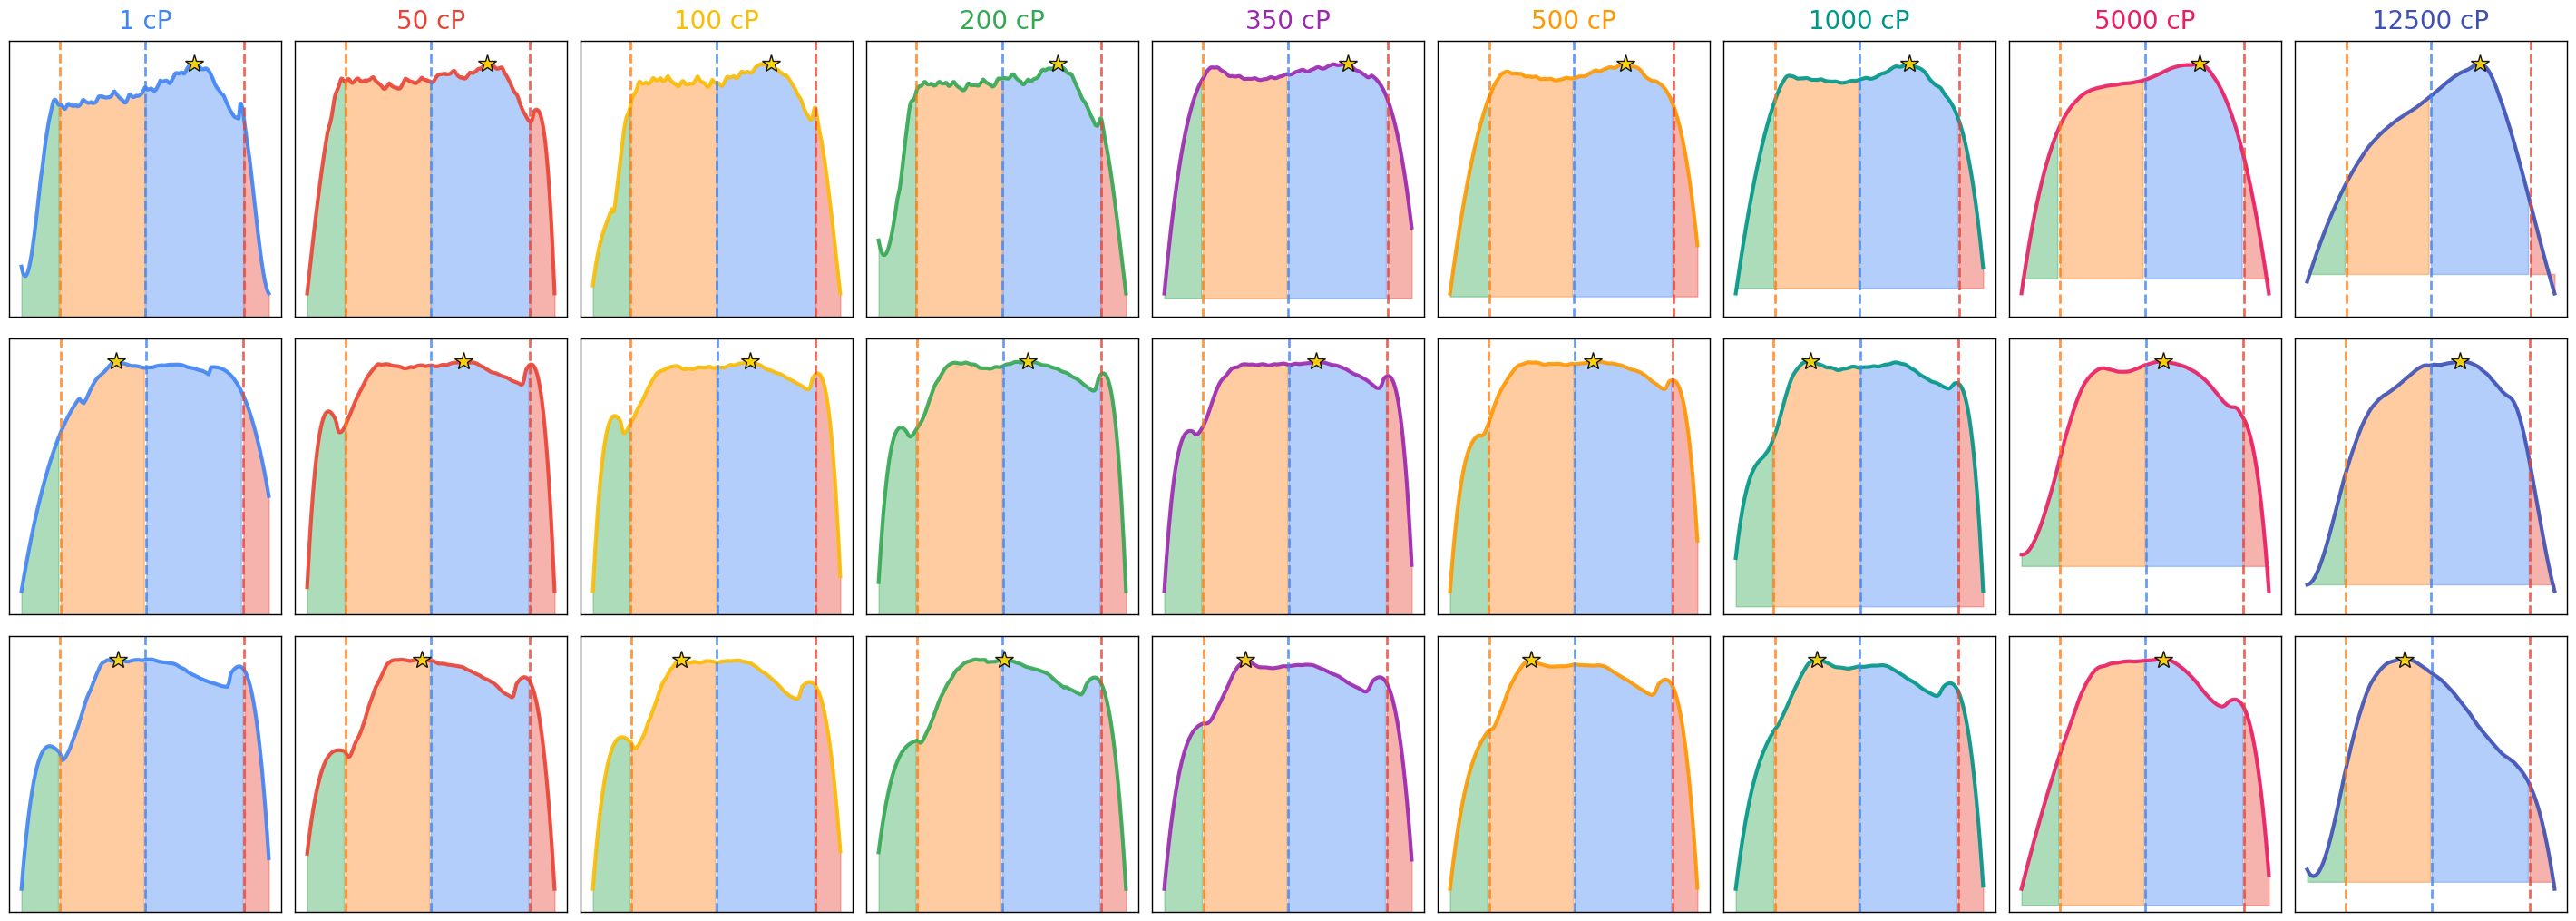

✅ PHASE DETECTION VISUALIZATION COMPLETE
🎯 Each subplot shows:
   - Colored line: Cycle data with normalized time from pipeline_results
   - Colored regions: Detected phases (Phase 1→Phase 2→Phase 3→Phase 4)
   - Gold star: Peak location
   - Dashed lines: Phase boundaries


In [27]:
# ===================================================================
# COMPREHENSIVE PHASE DETECTION VISUALIZATION (3x9 GRID)
# ===================================================================

def create_phase_detection_grid(results, datasets_dict):
    """Create 3x9 grid showing cycles with detected phases for each pump-sample combination"""
    
    # Google color palette for samples
    google_colors = {
        'blue': '#4285F4',
        'red': '#EA4335', 
        'yellow': '#FBBC04',
        'green': '#34A853',
        'purple': '#9C27B0',
        'orange': '#FF9800',
        'teal': '#009688',
        'pink': '#E91E63',
        'indigo': '#3F51B5'
    }
    
    # Phase colors for visualization
    phase_colors = {
        'phase1': "#34A853",  # Green - Phase 1
        'phase2': '#FF7D14',  # Orange - Phase 2
        'phase3': '#4285F4',  # Blue - Phase 3
        'phase4': "#EA4335"   # Red - Phase 4
    }
    
    dataset_names = list(datasets_dict.keys())  # ['2-Roller Pump', '3-Roller Pump', '4-Roller Pump']
    liquid_names = list(LIQUIDS_INFO.keys())[:MAX_LIQUIDS_TO_ANALYZE]
    color_list = list(google_colors.values())
    
    # Create 3x9 subplot grid with increased height
    fig, axes = plt.subplots(3, 9, figsize=(30, 12))
    
    # Plot each combination
    for dataset_idx, dataset_name in enumerate(dataset_names):
        dataset_results = results['datasets'][dataset_name]
        
        for liquid_idx, liquid_col in enumerate(liquid_names):
            ax = axes[dataset_idx, liquid_idx]
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            liquid_info = LIQUIDS_INFO[liquid_col]
            
            # Get color for this liquid
            color = color_list[liquid_idx % len(color_list)]
            
            # Clear the plot
            ax.clear()
            
            # Process results if available
            if liquid_name in dataset_results['liquid_results']:
                liquid_result = dataset_results['liquid_results'][liquid_name]
                
                if liquid_result['successful'] and liquid_result['cycles']:
                    # Get middle cycle as representative
                    middle_idx = len(liquid_result['cycles']) // 2
                    cycle = liquid_result['cycles'][middle_idx]
                    
                    # Apply phase detection directly on cycle data (no smoothing)
                    phases = detect_cycle_phases(cycle)
                    
                    if phases:
                        # Get cycle data directly from pipeline_results - already normalized!
                        normalized_time = cycle['cycle_time']  # Already normalized in detect_cycles_sinusoidal
                        cycle_flow = cycle['cycle_flow']
                        
                        # Plot cycle data as main line
                        ax.plot(normalized_time, cycle_flow, color=color, linewidth=3, 
                               alpha=0.9, label='Cycle Data')
                        
                        # Plot phase boundaries and segments
                        phase_names = ['Phase 1\n(Initial)', 'Phase 2\n(Rise)', 'Phase 3\n(Peak)', 'Phase 4\n(Descent)']
                        phase_keys = ['phase1', 'phase2', 'phase3', 'phase4']
                        
                        for i, (phase_key, phase_name) in enumerate(zip(phase_keys, phase_names)):
                            start_idx = phases[f'{phase_key}_start']
                            end_idx = phases[f'{phase_key}_end']
                            
                            # Ensure valid indices
                            if end_idx >= start_idx and start_idx < len(normalized_time):
                                # Highlight phase segment
                                phase_time = normalized_time[start_idx:end_idx+1]
                                phase_flow = cycle_flow[start_idx:end_idx+1]
                                
                                ax.fill_between(phase_time, 0, phase_flow, 
                                              color=phase_colors[phase_key], alpha=0.4,
                                              label=phase_name if dataset_idx == 0 and liquid_idx == 0 else "")
                                
                                # Add phase boundary lines
                                if i > 0:  # Don't draw line at the very beginning
                                    ax.axvline(normalized_time[start_idx], color=phase_colors[phase_key], 
                                             alpha=0.8, linestyle='--', linewidth=2)
                        
                        # Mark peak with special marker
                        peak_idx = phases['peak_idx']
                        if peak_idx < len(normalized_time):
                            ax.plot(normalized_time[peak_idx], cycle_flow[peak_idx], 
                                   marker='*', color='gold', markersize=15, 
                                   markeredgecolor='black', markeredgewidth=1, 
                                   alpha=0.9, zorder=10, label='Peak' if dataset_idx == 0 and liquid_idx == 0 else "")
                        
                        # Set individual axis ranges
                        time_margin = (max(normalized_time) - min(normalized_time)) * 0.05
                        if time_margin > 0:
                            xlim_individual = (min(normalized_time) - time_margin, max(normalized_time) + time_margin)
                        else:
                            xlim_individual = (min(normalized_time) - 2, max(normalized_time) + 2)
                        
                        ax.set_xlim(xlim_individual)
                        
                        flow_margin = (max(cycle_flow) - min(cycle_flow)) * 0.1
                        if flow_margin > 0:
                            ylim_individual = (min(cycle_flow) - flow_margin, max(cycle_flow) + flow_margin)
                        else:
                            ylim_individual = (min(cycle_flow) - 0.1, max(cycle_flow) + 0.1)
                        
                        ax.set_ylim(ylim_individual)
                        
                    else:
                        # Phase detection failed, show cycle data only
                        normalized_time = cycle['cycle_time']  # Already normalized
                        cycle_flow = cycle['cycle_flow']
                        
                        ax.plot(normalized_time, cycle_flow, color=color, linewidth=3, alpha=0.8)
                        ax.text(0.5, 0.5, 'Phase Detection\nFailed', 
                               transform=ax.transAxes, ha='center', va='center',
                               fontsize=12, color='orange', fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
                
                else:
                    # No successful cycle found
                    ax.text(0.5, 0.5, 'No\nCycles\nDetected', 
                           transform=ax.transAxes, ha='center', va='center',
                           fontsize=14, color='red', fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', alpha=0.8))
                    ax.set_xlim(0, 100)
                    ax.set_ylim(0, 1)
            
            else:
                # No data available
                ax.text(0.5, 0.5, 'No\nData\nAvailable', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=14, color='gray', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgray', alpha=0.8))
                ax.set_xlim(0, 100)
                ax.set_ylim(0, 1)
            
            # Formatting
            ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)
            ax.tick_params(labelsize=10)
            
            # Set all borders (spines) to black
            for spine in ax.spines.values():
                spine.set_color('black')
                spine.set_linewidth(1)

            # Column headers (liquid names) - only on top row
            if dataset_idx == 0:
                ax.set_title(f'{liquid_info["viscosity"]}', 
                           fontsize=20, color=color, pad=10)
            
            # Remove all tick labels for cleaner look
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.05, left=0.03, right=0.97, hspace=0.08, wspace=0.05)
    
    return fig

# Create and display the phase detection visualization
print("🎨 Creating comprehensive phase detection visualization...")
print("📊 Processing cycles with phase boundary detection (using normalized time from pipeline)...")

phase_detection_fig = create_phase_detection_grid(pipeline_results, datasets)
plt.show()

print("✅ PHASE DETECTION VISUALIZATION COMPLETE")
print("🎯 Each subplot shows:")
print("   - Colored line: Cycle data with normalized time from pipeline_results")
print("   - Colored regions: Detected phases (Phase 1→Phase 2→Phase 3→Phase 4)")
print("   - Gold star: Peak location")
print("   - Dashed lines: Phase boundaries")

🎯 Creating focused phase detection visualization for 4-Roller Pump with 1000 cP liquid...
📊 Using phase data directly from pipeline_results (no additional smoothing or phase detection)...


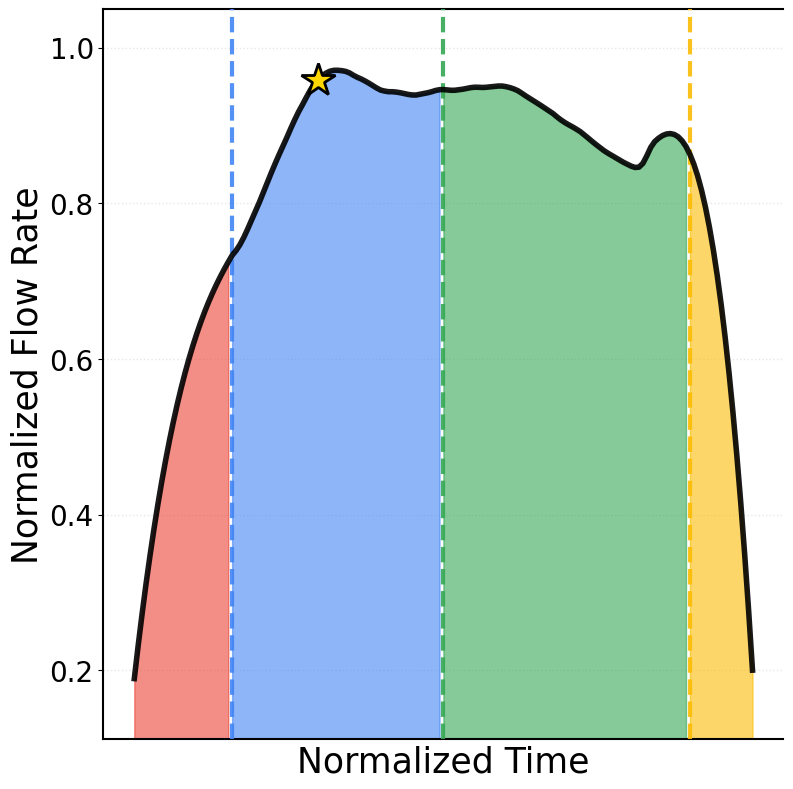

✅ FOCUSED PHASE ANALYSIS COMPLETE
🎯 Visualization shows:
   - Black line: Original cycle data with normalized time from pipeline_results
   - Colored regions: Phase segments from pipeline phase detection
   - Gold star: Peak location
   - Dashed lines: Phase boundaries
   - Title: Phase durations in seconds


In [28]:
# ===================================================================
# FOCUSED PHASE ANALYSIS: 4-ROLLER PUMP WITH 1000 cP LIQUID
# ===================================================================

def create_focused_phase_analysis(results, datasets_dict, target_pump='4-Roller Pump', target_liquid='F1000'):
    """Create detailed phase analysis visualization for specific pump-liquid combination"""
    
    # Google color palette - more distinguishable colors
    phase_colors = {
        'phase1': '#EA4335',  # Google Red - Initial Ramp
        'phase2': '#4285F4',  # Google Blue - Rise to Peak  
        'phase3': '#34A853',  # Google Green - Peak to Final
        'phase4': '#FBBC04'   # Google Yellow - Final Descent
    }
    
    # Create single figure for phase detection
    fig, ax = plt.subplots(1, 1, figsize=(8, 10))
    
    # Get the specific dataset and liquid data
    if target_pump in results['datasets']:
        dataset_results = results['datasets'][target_pump]
        
        if target_liquid in dataset_results['liquid_results']:
            liquid_result = dataset_results['liquid_results'][target_liquid]
            
            if liquid_result['successful'] and liquid_result['cycles']:
                # Get middle cycle as representative
                middle_idx = len(liquid_result['cycles']) // 2
                cycle = liquid_result['cycles'][middle_idx]
                
                # Check if phases are already detected in pipeline_results
                if 'phases' in cycle and cycle['phases'] is not None:
                    phases = cycle['phases']
                    
                    # Get cycle data directly from pipeline_results - already normalized!
                    normalized_time = cycle['cycle_time']  # Already normalized in detect_cycles_sinusoidal
                    cycle_flow = cycle['cycle_flow']
                    
                    # Plot cycle data as main line
                    ax.plot(normalized_time, cycle_flow, color='black', linewidth=4, 
                            alpha=0.9, label='Cycle Data', zorder=5)
                    
                    # Plot phase segments with fill
                    phase_names = ['Phase 1', 'Phase 2', 'Phase 3', 'Phase 4']
                    phase_keys = ['phase1', 'phase2', 'phase3', 'phase4']
                    
                    for i, (phase_key, phase_name) in enumerate(zip(phase_keys, phase_names)):
                        start_idx = phases[f'{phase_key}_start']
                        end_idx = phases[f'{phase_key}_end']
                        
                        # Ensure valid indices
                        if end_idx >= start_idx and start_idx < len(normalized_time):
                            phase_time = normalized_time[start_idx:end_idx+1]
                            phase_flow = cycle_flow[start_idx:end_idx+1]
                            
                            # Fill between with stronger alpha for better visibility
                            ax.fill_between(phase_time, 0, phase_flow, 
                                           color=phase_colors[phase_key], alpha=0.6, 
                                           label=phase_name, zorder=2)
                            
                            # Add phase boundary lines with matching colors
                            if i > 0:
                                ax.axvline(normalized_time[start_idx], color=phase_colors[phase_key], 
                                          alpha=0.9, linestyle='--', linewidth=3, zorder=4)
                    
                    # Mark peak with special marker
                    peak_idx = phases['peak_idx']
                    if peak_idx < len(normalized_time):
                        ax.plot(normalized_time[peak_idx], cycle_flow[peak_idx], 
                                marker='*', color='gold', markersize=25, 
                                markeredgecolor='black', markeredgewidth=2, 
                                alpha=1.0, zorder=10, label='Peak Point')
                                            
                    # Calculate phase durations for subtitle
                    phase_durations = {
                        'P1': normalized_time[phases['phase1_end']] - normalized_time[phases['phase1_start']],
                        'P2': normalized_time[phases['phase2_end']] - normalized_time[phases['phase2_start']],
                        'P3': normalized_time[phases['phase3_end']] - normalized_time[phases['phase3_start']],
                        'P4': normalized_time[phases['phase4_end']] - normalized_time[phases['phase4_start']]
                    }
                    
                    # Add title with phase duration info
                    duration_text = f"P1: {phase_durations['P1']:.1f}s | P2: {phase_durations['P2']:.1f}s | P3: {phase_durations['P3']:.1f}s | P4: {phase_durations['P4']:.1f}s"
                    #ax.set_title(f'{target_pump} - {target_liquid}\n{duration_text}', 
                    #            fontsize=16, fontweight='bold', pad=20)
                    
                    ax.set_xlabel('Normalized Time', fontsize=25)
                    ax.set_ylabel('Normalized Flow Rate', fontsize=25)
                    ax.grid(True, alpha=0.3, linestyle=':', linewidth=1)
                    #ax.legend(loc='lower center', fontsize=20, frameon=False)
                    
                    # Set nice axis limits with some padding
                    time_margin = (max(normalized_time) - min(normalized_time)) * 0.05
                    flow_margin = (max(cycle_flow) - min(cycle_flow)) * 0.1
                    ax.set_xlim(min(normalized_time) - time_margin, max(normalized_time) + time_margin)
                    ax.set_ylim(min(cycle_flow) - flow_margin, max(cycle_flow) + flow_margin)
                    
                    # Improve tick formatting
                    ax.set_xticks([])  # Remove x-axis numbers
                    ax.tick_params(axis='y', labelsize=20)  # Set y-axis fontsize to 20
                    
                    # Set solid black borders with thicker linewidth
                    for spine in ax.spines.values():
                        spine.set_color('black')
                        spine.set_linewidth(1.5)
                        spine.set_linestyle('-')
                        ax.spines['right'].set_visible(False)

                    
                else:
                    # Phase detection not available in pipeline results
                    ax.text(0.5, 0.5, 'Phase Detection Not Available\nfrom Pipeline Results', 
                           transform=ax.transAxes, ha='center', va='center',
                           fontsize=18, color='red', fontweight='bold')
                    #ax.set_title(f'{target_pump} - {target_liquid}: Phase Detection Not Available', 
                    #            fontsize=16, fontweight='bold')
            
            else:
                # No successful cycles
                ax.text(0.5, 0.5, 'No Cycles Detected', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=18, color='red', fontweight='bold')
                #ax.set_title(f'{target_pump} - {target_liquid}: No Cycles Detected', 
                #            fontsize=16, fontweight='bold')
        
        else:
            # Liquid not found
            ax.text(0.5, 0.5, f'Liquid {target_liquid} Not Found', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=18, color='gray', fontweight='bold')
            ax.set_title(f'{target_pump} - {target_liquid}: Data Not Available', 
                        fontsize=16, fontweight='bold')
    
    else:
        # Pump not found
        ax.text(0.5, 0.5, f'Pump {target_pump} Not Found', 
               transform=ax.transAxes, ha='center', va='center',
               fontsize=18, color='gray', fontweight='bold')
        #ax.set_title(f'{target_pump}: Data Not Available', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.12, left=0.10, right=0.95)
    
    return fig

# Create and display the focused phase analysis
print("🎯 Creating focused phase detection visualization for 4-Roller Pump with 1000 cP liquid...")
print("📊 Using phase data directly from pipeline_results (no additional smoothing or phase detection)...")

focused_analysis_fig = create_focused_phase_analysis(pipeline_results, datasets, 
                                                   target_pump='4-Roller Pump', 
                                                   target_liquid='F1000')
plt.show()

print("✅ FOCUSED PHASE ANALYSIS COMPLETE")
print("🎯 Visualization shows:")
print("   - Black line: Original cycle data with normalized time from pipeline_results")
print("   - Colored regions: Phase segments from pipeline phase detection")
print("   - Gold star: Peak location")
print("   - Dashed lines: Phase boundaries")
print("   - Title: Phase durations in seconds")

In [29]:
# ===================================================================
# CUSTOM SIGMOID FUNCTION FITTING FOR ALL DETECTED CYCLES
# ===================================================================

def custom_sigmoid_function(x, a1, a2, a3, a4, b1, b2, b3, b4, h1, h2, h3, h4, y_data=None):
    """
    Custom sigmoid function with mixed positive and negative sigmoid terms:
    y = h1/(1+exp(-(x-a1)/b1)) + h2/(1+exp(-(x-a2)/b2)) + h3/(1+exp(-(x-a3)/b3)) + h4/(1+exp(-(x-a4)/b4)) + c
    
    Parameters:
    - a1: position parameter for first sigmoid (has to be in phase 1)
    - a2: position parameter for second sigmoid (has to be less than median time and higher than a1)
    - a3: position parameter for third sigmoid (has to be in phase 3 and higher than a2)
    - a4: position parameter for fourth sigmoid (has to be higher than a3 and be in phase 4, a4 < 1)
    - b1, b2, b3, b4: slope parameters for the four sigmoid components (all positive and < 0.1)
    - h1, h2: positive amplitude scaling factors (< 0.1)
    - h3, h4: negative amplitude scaling factors (> -0.1)
    - y_data: the y data used to calculate c as minimum value (passed during fitting)
    
    Note: c is automatically set to min(y_data) and is not a fitted parameter
    
    Constraints:
    - a1: has to be in phase 1
    - a2: has to be less than median time and higher than a1
    - a3: has to be in phase 3 and higher than a2
    - a4: has to be higher than a3 and be in the phase 4 (a4<1)
    - b1, b2, b3, b4: all positive and < 0.1
    - h1, h2: positive and < 0.1
    - h3, h4: negative and > -0.1
    """
    # Calculate c as minimum of y_data
    if y_data is not None:
        c = np.min(y_data)
    else:
        c = 0  # Fallback if y_data not provided
    
    term1 = h1 / (1 + np.exp(-(x - a1) / b1))
    term2 = h2 / (1 + np.exp(-(x - a2) / b2))
    term3 = h3 / (1 + np.exp(-(x - a3) / b3))
    term4 = h4 / (1 + np.exp(-(x - a4) / b4))
    
    return term1 + term2 + term3 + term4 + c

def fit_custom_sigmoid_to_cycle(cycle_data, max_attempts=10):
    """
    Fit the custom sigmoid function to a single cycle with robust parameter initialization
    
    Updated Constraints:
    - a1: has to be in phase 1
    - a2: has to be less than median time and higher than a1
    - a3: has to be in phase 3 and higher than a2
    - a4: has to be higher than a3 and be in phase 4 (a4<1)
    - b1, b2, b3, b4: all positive and < 0.1
    - h1, h2: positive and < 1.0 (updated for normalized y-axis)
    - h3, h4: negative and > -1.0 (updated for normalized y-axis)
    - c: automatically set to min(cycle_flow) - not a fitted parameter
    """
    cycle_time = cycle_data['cycle_time']  # Already normalized from detect_cycles_sinusoidal
    cycle_flow = cycle_data['cycle_flow']
    
    # Get phase information if available for better positioning
    phases = cycle_data.get('phases', None)
    
    # Calculate median time for constraint
    median_time = 0.5  # Since time is normalized 0-1, median is 0.5
    
    # Create wrapper function for fitting all parameters
    def sigmoid_wrapper(x, a1, a2, a3, a4, b1, b2, b3, b4, h1, h2, h3, h4):
        return custom_sigmoid_function(x, a1, a2, a3, a4, b1, b2, b3, b4, h1, h2, h3, h4, y_data=cycle_flow)
    
    # Calculate basic statistics for parameter initialization
    flow_min = np.min(cycle_flow)
    flow_max = np.max(cycle_flow)
    flow_range = flow_max - flow_min
    
    # Setup normalized time (cycle_time should already be normalized from detect_cycles_sinusoidal)
    normalized_time = cycle_time
    
    # Get phase information if available for better positioning
    if phases:
        # Use phase boundaries for positioning (convert indices to normalized positions)
        phase1_start = phases['phase1_start'] / len(normalized_time) if len(normalized_time) > 0 else 0.0
        phase1_end = phases['phase1_end'] / len(normalized_time) if len(normalized_time) > 0 else 0.25
        phase3_start = phases.get('phase3_start', phases['phase2_end']) / len(normalized_time) if len(normalized_time) > 0 else 0.5
        phase3_end = phases.get('phase3_end', phases['phase4_start']) / len(normalized_time) if len(normalized_time) > 0 else 0.75
        phase4_start = phases['phase4_start'] / len(normalized_time) if len(normalized_time) > 0 else 0.75
        phase4_end = phases['phase4_end'] / len(normalized_time) if len(normalized_time) > 0 else 1.0
    else:
        # Fallback to default phase estimates
        phase1_start, phase1_end = 0.0, 0.25
        phase3_start, phase3_end = 0.5, 0.75
        phase4_start, phase4_end = 0.75, 1.0
        
    # Find peak location for better initialization
    peak_idx = np.argmax(cycle_flow)
    peak_time = normalized_time[peak_idx]
    
    for attempt in range(max_attempts):
        try:
            # Adaptive parameter initialization - gets more flexible with each attempt
            noise_factor = 0.005 + 0.005 * attempt  # Smaller noise for tight constraints
            
            # Initialize positions with constraints
            # a1: has to be in phase 1
            a1_init = phase1_start + (phase1_end - phase1_start) * np.random.random() + np.random.normal(0, noise_factor)
            a1_init = max(phase1_start, min(phase1_end, a1_init))
            
            # a2: has to be less than median time and higher than a1
            a2_max = min(median_time, phase3_start)
            a2_init = a1_init + 0.01 + (a2_max - a1_init - 0.01) * np.random.random() + np.random.normal(0, noise_factor)
            a2_init = max(a1_init + 0.01, min(a2_max, a2_init))
            
            # a3: has to be in phase 3 and higher than a2
            a3_init = max(a2_init + 0.01, phase3_start) + (phase3_end - max(a2_init + 0.01, phase3_start)) * np.random.random() + np.random.normal(0, noise_factor)
            a3_init = max(a2_init + 0.01, min(phase3_end, a3_init))
            
            # a4: has to be higher than a3 and be in the phase 4 (a4<1)
            a4_init = max(a3_init + 0.01, phase4_start) + (0.99 - max(a3_init + 0.01, phase4_start)) * np.random.random() + np.random.normal(0, noise_factor)
            a4_init = max(a3_init + 0.01, min(0.99, a4_init))
            
            # Initialize slope parameters (< 0.1)
            base_slope = 0.01 + 0.05 * np.random.random()  # 0.01-0.06 range
            b1_init = max(0.001, min(0.099, base_slope + np.random.normal(0, 0.01)))
            b2_init = max(0.001, min(0.099, base_slope + np.random.normal(0, 0.01)))
            b3_init = max(0.001, min(0.099, base_slope + np.random.normal(0, 0.01)))
            b4_init = max(0.001, min(0.099, base_slope + np.random.normal(0, 0.01)))
            
            # Initialize Amplitudes h1, h2 (positive), h3, h4 (negative) - Updated for normalized data
            base_amplitude = 0.1 + 0.4 * np.random.random()  # 0.1-0.5 range for normalized data
            h1_init = max(0.01, min(0.99, base_amplitude + np.random.normal(0, 0.05)))
            h2_init = max(0.01, min(0.99, base_amplitude + np.random.normal(0, 0.05)))
            h3_init = max(-0.99, min(-0.01, -base_amplitude + np.random.normal(0, 0.05)))
            h4_init = max(-0.99, min(-0.01, -base_amplitude + np.random.normal(0, 0.05)))
            
            # Set bounds for all parameters
            bounds_lower = [
                phase1_start,  # a1: in phase 1
                max(a1_init + 0.001, phase1_start + 0.001),  # a2: higher than a1
                max(phase3_start, a2_init + 0.001),  # a3: in phase 3 and higher than a2
                max(phase4_start, a3_init + 0.001),  # a4: in phase 4 and higher than a3
                0.001, 0.001, 0.001, 0.001,  # b1, b2, b3, b4: positive
                0.01, 0.01, -0.99, -0.99   # h1, h2: positive, h3, h4: negative
            ]
            
            bounds_upper = [
                phase1_end,  # a1: in phase 1
                min(median_time, phase3_start - 0.001),  # a2: less than median time
                min(phase3_end, phase4_start - 0.001),  # a3: in phase 3
                0.99,  # a4: < 1
                0.099, 0.099, 0.099, 0.099,  # b1, b2, b3, b4: < 0.1
                0.99, 0.99, -0.01, -0.01   # h1, h2: < 1.0, h3, h4: > -1.0
            ]
            
            bounds = (bounds_lower, bounds_upper)
            
            # Initial parameter vector (all 12 parameters)
            p0 = [a1_init, a2_init, a3_init, a4_init, b1_init, b2_init, b3_init, b4_init, h1_init, h2_init, h3_init, h4_init]
            
            # Perform curve fitting
            fitted_params, covariance = curve_fit(
                sigmoid_wrapper, 
                normalized_time, 
                cycle_flow,
                p0=p0,
                bounds=bounds,
                maxfev=8000,
                method='trf'
            )
            
            # Extract fitted parameters
            a1_fit, a2_fit, a3_fit, a4_fit = fitted_params[:4]
            b1_fit, b2_fit, b3_fit, b4_fit = fitted_params[4:8]
            h1_fit, h2_fit, h3_fit, h4_fit = fitted_params[8:12]
            c_fit = flow_min
            
            # Validate constraints
            phase1_ok = phase1_start <= a1_fit <= phase1_end
            a2_ok = a1_fit < a2_fit < median_time
            phase3_ok = phase3_start <= a3_fit <= phase3_end and a2_fit < a3_fit
            phase4_ok = phase4_start <= a4_fit < 1.0 and a3_fit < a4_fit
            ordering_ok = a1_fit < a2_fit < a3_fit < a4_fit
            slopes_ok = all(0 < p < 0.1 for p in [b1_fit, b2_fit, b3_fit, b4_fit])
            amplitudes_ok = (0 < h1_fit < 1.0 and 0 < h2_fit < 1.0 and 
                           -1.0 < h3_fit < 0 and -1.0 < h4_fit < 0)
            
            constraints_ok = phase1_ok and a2_ok and phase3_ok and phase4_ok and ordering_ok and slopes_ok and amplitudes_ok
            
            if not constraints_ok:
                raise ValueError(f"Constraint violation: a1={a1_fit:.4f} (phase1: {phase1_ok}), a2={a2_fit:.4f} (<median & >a1: {a2_ok}), a3={a3_fit:.4f} (phase3 & >a2: {phase3_ok}), a4={a4_fit:.4f} (phase4 & <1 & >a3: {phase4_ok})")
            
            # Calculate fit quality using the fitted values
            fitted_values = custom_sigmoid_function(normalized_time, a1_fit, a2_fit, a3_fit, a4_fit, b1_fit, b2_fit, b3_fit, b4_fit, h1_fit, h2_fit, h3_fit, h4_fit, y_data=cycle_flow)
            ss_res = np.sum((cycle_flow - fitted_values) ** 2)
            ss_tot = np.sum((cycle_flow - np.mean(cycle_flow)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Create parameter errors array
            param_errors = np.full(13, np.nan)  # 13 total parameters including c
            if covariance is not None:
                fitted_errors = np.sqrt(np.diag(covariance))
                param_errors[:12] = fitted_errors  # First 12 are fitted parameters
                param_errors[12] = 0.0  # c is fixed
            
            # Print successful fit info for debugging
            if attempt > 0:
                print(f"   ✅ Success on attempt {attempt + 1}: R²={r_squared:.3f}, constraints satisfied")
            
            # Combine all parameters in correct order: [a1, a2, a3, a4, b1, b2, b3, b4, h1, h2, h3, h4, c]
            all_fitted_params = np.array([a1_fit, a2_fit, a3_fit, a4_fit, b1_fit, b2_fit, b3_fit, b4_fit, h1_fit, h2_fit, h3_fit, h4_fit, c_fit])
            
            return {
                'success': True,
                'fitted_params': all_fitted_params,
                'param_names': ['a1', 'a2', 'a3', 'a4', 'b1', 'b2', 'b3', 'b4', 'h1', 'h2', 'h3', 'h4', 'c'],
                'param_errors': param_errors,
                'fitted_values': fitted_values,
                'normalized_time': normalized_time,  # Already normalized
                'original_time': cycle_data.get('original_cycle_time', cycle_time),  # Use original if available
                'original_flow': cycle_flow,
                'r_squared': r_squared,
                'attempt': attempt + 1,
                'c_fixed': True,
                'c_value': c_fit
            }
            
        except Exception as e:
            # Print more detailed error info for debugging
            if attempt < 3:
                print(f"   Attempt {attempt + 1} failed: {str(e)[:100]}")
            
            if attempt == max_attempts - 1:
                print(f"   ❌ All {max_attempts} attempts failed. Last error: {str(e)[:150]}")
                return {
                    'success': False,
                    'error': str(e),
                    'normalized_time': normalized_time,  # Already normalized
                    'original_time': cycle_data.get('original_cycle_time', cycle_time),
                    'original_flow': cycle_flow,
                    'attempts_made': max_attempts
                }
            continue

def fit_sigmoid_to_all_cycles(pipeline_results):
    """
    Fit custom sigmoid function to all detected cycles in pipeline results
    """
    print("🔧 FITTING CUSTOM SIGMOID FUNCTION TO ALL DETECTED CYCLES")
    print("📋 Updated Constraints:")
    print("   • a1: has to be in phase 1")
    print("   • a2: has to be less than median time and higher than a1")
    print("   • a3: has to be in phase 3 and higher than a2")
    print("   • a4: has to be higher than a3 and be in phase 4 (a4<1)")
    print("   • b1, b2, b3, b4: all positive and < 0.1")
    print("   • h1, h2: positive and < 1.0")
    print("   • h3, h4: negative and > -1.0")
    print("   • c: automatically set to min(flow) for each cycle (not fitted)")
    print("=" * 60)
    
    fitting_results = {
        'datasets': {},
        'summary': {
            'total_cycles': 0,
            'successful_fits': 0,
            'failed_fits': 0,
            'success_rate': 0.0
        }
    }
    
    for dataset_name, dataset_data in pipeline_results['datasets'].items():
        print(f"\n📊 Processing {dataset_name}...")
        
        dataset_fitting = {
            'liquids': {},
            'successful_fits': 0,
            'failed_fits': 0,
            'total_cycles': 0
        }
        
        for liquid_name, liquid_result in dataset_data['liquid_results'].items():
            if liquid_result['successful'] and liquid_result['cycles']:
                liquid_fitting = {
                    'cycles': [],
                    'successful_fits': 0,
                    'failed_fits': 0
                }
                
                print(f"   🎯 {liquid_name}: {len(liquid_result['cycles'])} cycles...", end=' ')
                
                for cycle_idx, cycle in enumerate(liquid_result['cycles']):
                    fit_result = fit_custom_sigmoid_to_cycle(cycle)
                    fit_result['cycle_number'] = cycle_idx + 1
                    fit_result['liquid_name'] = liquid_name
                    fit_result['dataset_name'] = dataset_name
                    
                    liquid_fitting['cycles'].append(fit_result)
                    dataset_fitting['total_cycles'] += 1
                    fitting_results['summary']['total_cycles'] += 1
                    
                    if fit_result['success']:
                        liquid_fitting['successful_fits'] += 1
                        dataset_fitting['successful_fits'] += 1
                        fitting_results['summary']['successful_fits'] += 1
                    else:
                        liquid_fitting['failed_fits'] += 1
                        dataset_fitting['failed_fits'] += 1
                        fitting_results['summary']['failed_fits'] += 1
                
                # Calculate liquid-level statistics
                total_liquid_cycles = liquid_fitting['successful_fits'] + liquid_fitting['failed_fits']
                liquid_success_rate = liquid_fitting['successful_fits'] / total_liquid_cycles * 100 if total_liquid_cycles > 0 else 0
                
                print(f"✅ {liquid_fitting['successful_fits']}/{total_liquid_cycles} ({liquid_success_rate:.0f}%)")
                
                dataset_fitting['liquids'][liquid_name] = liquid_fitting
            
            else:
                print(f"   ⏭️  {liquid_name}: No cycles to fit")
        
        fitting_results['datasets'][dataset_name] = dataset_fitting
        
        # Dataset summary
        dataset_success_rate = dataset_fitting['successful_fits'] / dataset_fitting['total_cycles'] * 100 if dataset_fitting['total_cycles'] > 0 else 0
        print(f"   📈 Dataset success: {dataset_fitting['successful_fits']}/{dataset_fitting['total_cycles']} ({dataset_success_rate:.1f}%)")
    print(f"   🎯 Total cycles processed: {fitting_results['summary']['total_cycles']}")
    # Calculate overall summary
    fitting_results['summary']['success_rate'] = fitting_results['summary']['successful_fits'] / fitting_results['summary']['total_cycles'] * 100 if fitting_results['summary']['total_cycles'] > 0 else 0
    
    print(f"\n📊 SIGMOID FITTING SUMMARY:")
    print(f"   🎯 Total cycles processed: {fitting_results['summary']['total_cycles']}")
    print(f"   ✅ Successful fits: {fitting_results['summary']['successful_fits']}")
    print(f"   ❌ Failed fits: {fitting_results['summary']['failed_fits']}")
    print(f"   📈 Overall success rate: {fitting_results['summary']['success_rate']:.1f}%")
    
    print(f"✅ SIGMOID FITTING COMPLETE!")
    print(f"   ⏱️  Using normalized time from pipeline_results with updated constraints")
    
    return fitting_results

sigmoid_fitting_results = fit_sigmoid_to_all_cycles(pipeline_results)

🔧 FITTING CUSTOM SIGMOID FUNCTION TO ALL DETECTED CYCLES
📋 Updated Constraints:
   • a1: has to be in phase 1
   • a2: has to be less than median time and higher than a1
   • a3: has to be in phase 3 and higher than a2
   • a4: has to be higher than a3 and be in phase 4 (a4<1)
   • b1, b2, b3, b4: all positive and < 0.1
   • h1, h2: positive and < 1.0
   • h3, h4: negative and > -1.0
   • c: automatically set to min(flow) for each cycle (not fitted)

📊 Processing 2-Roller Pump...
   🎯 CF955: 5 cycles... ✅ 5/5 (100%)
   🎯 F50: 4 cycles... ✅ 4/4 (100%)
   🎯 F100: 8 cycles...    Attempt 1 failed: Constraint violation: a1=0.1124 (phase1: True), a2=0.0783 (<median & >a1: False), a3=0.8554 (phase3 
   Attempt 2 failed: Initial guess is outside of provided bounds
   ✅ Success on attempt 3: R²=0.985, constraints satisfied


C:\Users\mrast\AppData\Local\Temp\ipykernel_31696\3840570168.py:39: RuntimeWarning: overflow encountered in exp
  term3 = h3 / (1 + np.exp(-(x - a3) / b3))


✅ 8/8 (100%)
   🎯 F200: 6 cycles... ✅ 6/6 (100%)
   🎯 F350: 9 cycles... ✅ 9/9 (100%)
   🎯 F500: 5 cycles... ✅ 5/5 (100%)
   🎯 F1000: 5 cycles... ✅ 5/5 (100%)
   🎯 F5000: 6 cycles... ✅ 6/6 (100%)
   🎯 F12500: 5 cycles... ✅ 5/5 (100%)
   📈 Dataset success: 53/53 (100.0%)

📊 Processing 3-Roller Pump...
   🎯 CF955: 9 cycles... ✅ 9/9 (100%)
   🎯 F50: 5 cycles... ✅ 5/5 (100%)
   🎯 F100: 6 cycles... ✅ 6/6 (100%)
   🎯 F200: 7 cycles... ✅ 7/7 (100%)
   🎯 F350: 6 cycles... ✅ 6/6 (100%)
   🎯 F500: 7 cycles... ✅ 7/7 (100%)
   🎯 F1000: 6 cycles... ✅ 6/6 (100%)
   🎯 F5000: 9 cycles... 

C:\Users\mrast\AppData\Local\Temp\ipykernel_31696\3840570168.py:40: RuntimeWarning: overflow encountered in exp
  term4 = h4 / (1 + np.exp(-(x - a4) / b4))


   Attempt 1 failed: Initial guess is outside of provided bounds
   ✅ Success on attempt 2: R²=0.999, constraints satisfied
   Attempt 1 failed: Initial guess is outside of provided bounds
   ✅ Success on attempt 2: R²=0.999, constraints satisfied
✅ 9/9 (100%)
   🎯 F12500: 6 cycles...    Attempt 1 failed: Constraint violation: a1=0.1507 (phase1: True), a2=0.1494 (<median & >a1: False), a3=0.7345 (phase3 
   Attempt 2 failed: Constraint violation: a1=0.1507 (phase1: True), a2=0.1494 (<median & >a1: False), a3=0.7345 (phase3 
   Attempt 3 failed: Initial guess is outside of provided bounds
   ✅ Success on attempt 4: R²=0.999, constraints satisfied
✅ 6/6 (100%)
   📈 Dataset success: 61/61 (100.0%)

📊 Processing 4-Roller Pump...
   🎯 CF955: 9 cycles... ✅ 9/9 (100%)
   🎯 F50: 7 cycles...    Attempt 1 failed: Constraint violation: a1=0.1463 (phase1: True), a2=0.0313 (<median & >a1: False), a3=0.6672 (phase3 
   ✅ Success on attempt 2: R²=0.996, constraints satisfied
✅ 7/7 (100%)
   🎯 F100: 8

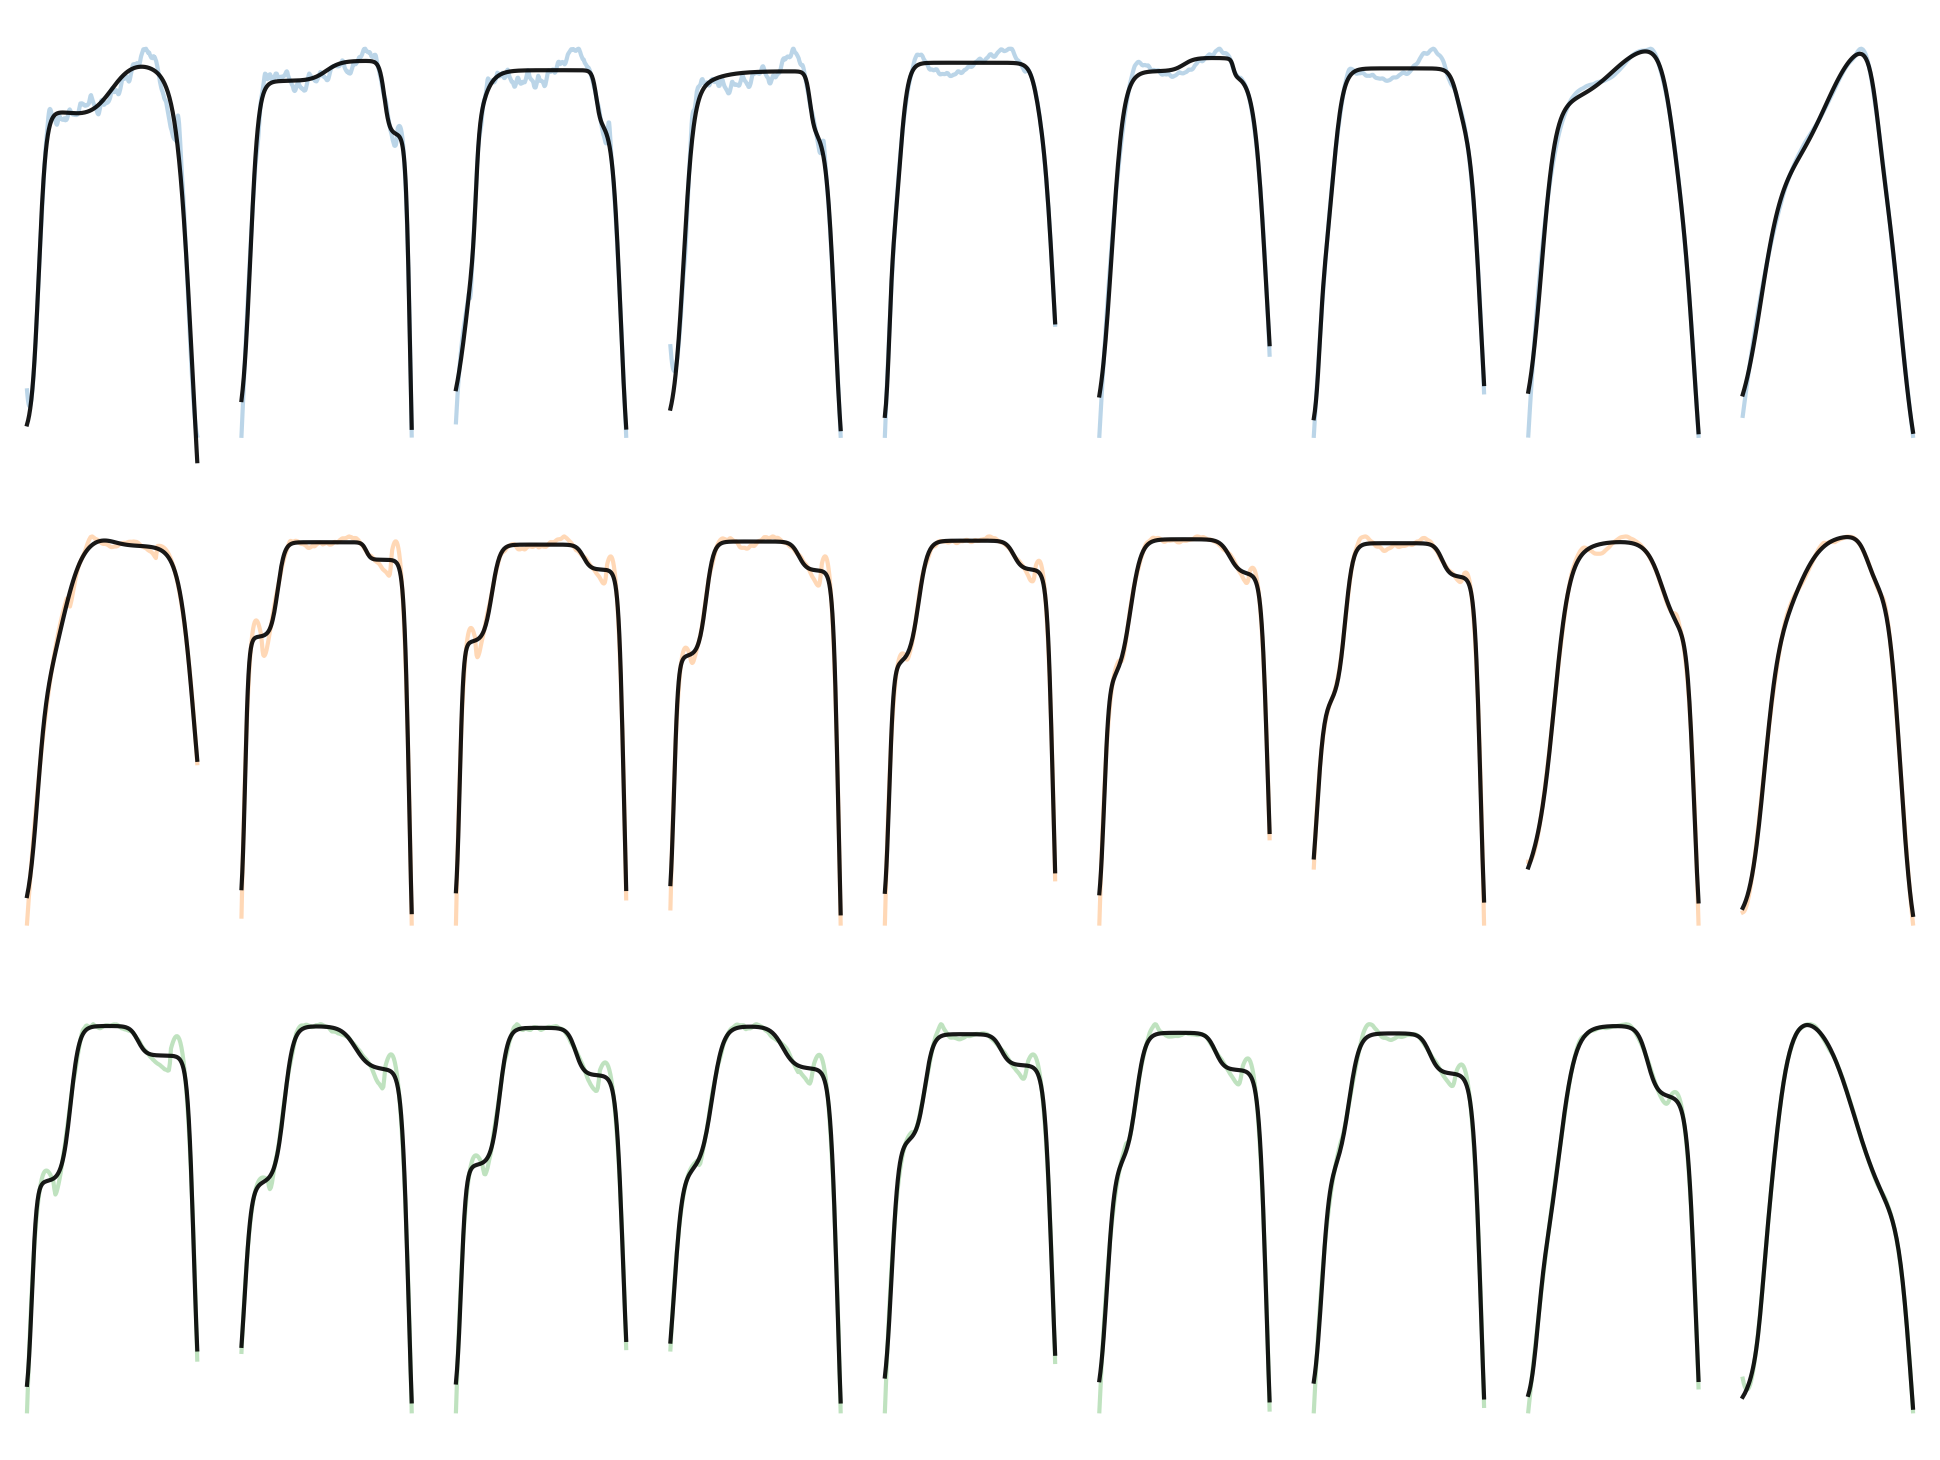

In [30]:
# ===================================================================
# COMPREHENSIVE SIGMOID FITTING VISUALIZATION
# ===================================================================

def create_sigmoid_fitting_visualization(sigmoid_results, datasets_dict):
    """Create comprehensive visualization showing original cycles and fitted sigmoid curves"""
    dataset_names = list(datasets_dict.keys())
    liquid_names = list(LIQUIDS_INFO.keys())[:MAX_LIQUIDS_TO_ANALYZE]
    
    # Create subplot grid with larger figure size
    fig, axes = plt.subplots(len(dataset_names), len(liquid_names), figsize=(20, 15))
    if len(dataset_names) == 1:
        axes = axes.reshape(1, -1)
    
    # Colors for each pump configuration
    pump_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # Plot each combination
    for dataset_idx, (dataset_name, df) in enumerate(datasets_dict.items()):
        if dataset_name not in sigmoid_results['datasets']:
            continue
            
        dataset_results = sigmoid_results['datasets'][dataset_name]
        pump_color = pump_colors[dataset_idx]
        
        for liquid_idx, liquid_col in enumerate(liquid_names):
            ax = axes[dataset_idx, liquid_idx]
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            liquid_info = LIQUIDS_INFO[liquid_col]
            
            # Process sigmoid fitting results if available
            if liquid_name in dataset_results['liquids']:
                liquid_fitting = dataset_results['liquids'][liquid_name]
                cycles_with_fits = liquid_fitting['cycles']
                
                successful_cycles = [c for c in cycles_with_fits if c['success']]
                
                if successful_cycles:
                    # Select middle cycle as representative
                    middle_idx = len(successful_cycles) // 2
                    cycle_fit = successful_cycles[middle_idx]
                    
                    original_time = cycle_fit['original_time']
                    original_flow = cycle_fit['original_flow']
                    fitted_values = cycle_fit['fitted_values']
                    r_squared = cycle_fit['r_squared']
                    
                    # Get fitted parameters
                    fitted_params = cycle_fit['fitted_params']
                    
                    # Normalize time to start from 0 for better comparison across subplots
                    normalized_time = original_time - original_time[0]
                    
                    # Plot original cycle data (transparent)
                    ax.plot(normalized_time, original_flow, color=pump_color, linewidth=3, 
                           alpha=0.3, zorder=3)
                    
                    # Plot fitted sigmoid curve (solid line)
                    ax.plot(normalized_time, fitted_values, color='black', linewidth=3, 
                           alpha=0.9, linestyle='-', zorder=4)
                    
                    # Adjust x-axis to focus on the cycle with some padding
                    time_range = normalized_time[-1] - normalized_time[0]
                    padding = time_range * 0.1  # 10% padding on each side
                    ax.set_xlim(normalized_time[0] - padding, normalized_time[-1] + padding)
                    
                    # Adjust y-axis to focus on the cycle flow range
                    flow_range = np.max(original_flow) - np.min(original_flow)
                    flow_padding = flow_range * 0.1  # 10% padding on top and bottom
                    ax.set_ylim(np.min(original_flow) - flow_padding, 
                               np.max(original_flow) + flow_padding)
            
            # Remove all axis labels, ticks, and numbers
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')
            
            # Remove grid and spines for cleaner look
            ax.grid(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
    
    # Minimize spacing between subplots to make visualization bigger
    plt.subplots_adjust(left=0.02, bottom=0.02, right=0.98, top=0.98, 
                        wspace=0.05, hspace=0.05)
    return fig

# Create and display comprehensive sigmoid fitting visualization
sigmoid_fitting_figure = create_sigmoid_fitting_visualization(sigmoid_fitting_results, datasets)
plt.show()

In [31]:
# ===================================================================
# COMPREHENSIVE CYCLE DATASET CREATION
# ===================================================================

def create_comprehensive_cycle_dataset(pipeline_results, sigmoid_results):
    """
    Create a comprehensive dataset with all cycle features for machine learning:
    - a1, a2, a3, a4 (sigmoid position parameters)
    - h1, h2, h3, h4 (sigmoid amplitude parameters)
    - b1, b2, b3, b4 (sigmoid slope parameters)
    - sample name
    - pump rollers (number of rollers: 2, 3, or 4)
    - cycle number
    - duration_sec (un-normalized, in seconds)
    - flow_max_ml_min, flow_min_ml_min (un-normalized, in ml/min)
    - viscosity of the sample (cP) - this is the label
    """
    print("📊 CREATING COMPREHENSIVE CYCLE DATASET")
    print("=" * 60)
    
    all_cycle_data = []
    
    for dataset_name, dataset_data in pipeline_results['datasets'].items():
        print(f"\n📈 Processing {dataset_name}...")
        
        # Extract pump roller count from dataset name
        if "2-Roller" in dataset_name:
            pump_rollers = 2
        elif "3-Roller" in dataset_name:
            pump_rollers = 3
        elif "4-Roller" in dataset_name:
            pump_rollers = 4
        else:
            pump_rollers = 0  # Unknown configuration
        
        for liquid_name, liquid_result in dataset_data['liquid_results'].items():
            if not (liquid_result['successful'] and liquid_result['cycles']):
                continue
                
            # Get viscosity value from LIQUIDS_INFO
            liquid_key = f"{liquid_name}_flow_ml_min"
            if liquid_key in LIQUIDS_INFO:
                viscosity_str = LIQUIDS_INFO[liquid_key]['viscosity']
                # Extract numeric viscosity value (remove 'cP' and convert to float)
                viscosity_cp = float(viscosity_str.replace(' cP', ''))
            else:
                print(f"   ⚠️ Viscosity info not found for {liquid_name}, skipping...")
                continue
            
            # Get sigmoid fitting results for this liquid if available
            sigmoid_available = False
            sigmoid_cycles = []
            if (dataset_name in sigmoid_results['datasets'] and 
                liquid_name in sigmoid_results['datasets'][dataset_name]['liquids']):
                sigmoid_cycles = sigmoid_results['datasets'][dataset_name]['liquids'][liquid_name]['cycles']
                sigmoid_available = True
            
            print(f"   🎯 {liquid_name} ({viscosity_cp} cP): {len(liquid_result['cycles'])} cycles...", end=' ')
            
            cycles_processed = 0
            cycles_with_sigmoid = 0
            
            for cycle_idx, cycle in enumerate(liquid_result['cycles']):
                # Get sigmoid parameters if available for this cycle
                sigmoid_params = None
                if sigmoid_available and cycle_idx < len(sigmoid_cycles):
                    sigmoid_fit = sigmoid_cycles[cycle_idx]
                    if sigmoid_fit['success']:
                        sigmoid_params = sigmoid_fit['fitted_params']
                        cycles_with_sigmoid += 1
                
                # Calculate un-normalized duration, max, and min from cycle data
                cycle_time = cycle['cycle_time']
                cycle_flow = cycle['cycle_flow']
                
                # Get original (un-normalized) data if available
                if 'original_cycle_time' in cycle:
                    original_time = cycle['original_cycle_time']
                    original_flow = cycle.get('original_cycle_flow', cycle_flow)
                else:
                    # Use current data as fallback
                    original_time = cycle_time
                    original_flow = cycle_flow
                
                # Calculate features with proper units
                duration_sec = float(original_time[-1] - original_time[0]) if len(original_time) > 1 else 0.0
                flow_max_ml_min = float(np.max(original_flow))
                flow_min_ml_min = float(np.min(original_flow))
                
                # Create cycle record
                cycle_record = {
                    'sample_name': liquid_name,
                    'pump_rollers': pump_rollers, 
                    'cycle_number': cycle_idx + 1,
                    'duration_sec': duration_sec,
                    'flow_max_ml_min': flow_max_ml_min,
                    'flow_min_ml_min': flow_min_ml_min,
                    'viscosity_cp': viscosity_cp,
                    'has_sigmoid_fit': sigmoid_params is not None
                }
                
                # Add sigmoid parameters if available
                if sigmoid_params is not None:
                    param_names = ['a1', 'a2', 'a3', 'a4', 'b1', 'b2', 'b3', 'b4', 'h1', 'h2', 'h3', 'h4']
                    for i, param_name in enumerate(param_names):
                        cycle_record[param_name] = float(sigmoid_params[i])
                else:
                    # Fill with NaN if sigmoid fitting not available
                    param_names = ['a1', 'a2', 'a3', 'a4', 'b1', 'b2', 'b3', 'b4', 'h1', 'h2', 'h3', 'h4']
                    for param_name in param_names:
                        cycle_record[param_name] = np.nan
                
                all_cycle_data.append(cycle_record)
                cycles_processed += 1
            
            print(f"✅ {cycles_processed} cycles, {cycles_with_sigmoid} with sigmoid fits")
    
    # Convert to DataFrame
    cycle_dataset = pd.DataFrame(all_cycle_data)
    
    # Check if has_sigmoid_fit column should be removed (if all values are True)
    if cycle_dataset['has_sigmoid_fit'].all():
        print("   🔧 Removing 'has_sigmoid_fit' column (all values are True)")
        cycle_dataset = cycle_dataset.drop('has_sigmoid_fit', axis=1)
        include_sigmoid_fit = False
    else:
        include_sigmoid_fit = True
    
    # Reorder columns for better readability
    column_order = [
        'sample_name', 'pump_rollers', 'cycle_number',
        'a1', 'a2', 'a3', 'a4',
        'h1', 'h2', 'h3', 'h4', 
        'b1', 'b2', 'b3', 'b4',
        'duration_sec', 'flow_max_ml_min', 'flow_min_ml_min',
        'viscosity_cp'
    ]
    
    if include_sigmoid_fit:
        column_order.append('has_sigmoid_fit')
    
    cycle_dataset = cycle_dataset[column_order]
    
    print(f"\n📊 DATASET CREATION SUMMARY:")
    print(f"   🎯 Total cycles: {len(cycle_dataset)}")
    print(f"   📈 Unique samples: {cycle_dataset['sample_name'].nunique()}")
    print(f"   🔬 Pump configurations: {sorted(cycle_dataset['pump_rollers'].unique())}")
    if include_sigmoid_fit:
        print(f"   ✅ Cycles with sigmoid fits: {cycle_dataset['has_sigmoid_fit'].sum()}")
    else:
        print(f"   ✅ All cycles have sigmoid fits")
    print(f"   📊 Viscosity range: {cycle_dataset['viscosity_cp'].min():.0f} - {cycle_dataset['viscosity_cp'].max():.0f} cP")
    print(f"✅ COMPREHENSIVE CYCLE DATASET CREATED!")
    
    return cycle_dataset

# Create the comprehensive dataset
comprehensive_cycle_dataset = create_comprehensive_cycle_dataset(pipeline_results, sigmoid_fitting_results)

📊 CREATING COMPREHENSIVE CYCLE DATASET

📈 Processing 2-Roller Pump...
   🎯 CF955 (1.0 cP): 5 cycles... ✅ 5 cycles, 5 with sigmoid fits
   🎯 F50 (50.0 cP): 4 cycles... ✅ 4 cycles, 4 with sigmoid fits
   🎯 F100 (100.0 cP): 8 cycles... ✅ 8 cycles, 8 with sigmoid fits
   🎯 F200 (200.0 cP): 6 cycles... ✅ 6 cycles, 6 with sigmoid fits
   🎯 F350 (350.0 cP): 9 cycles... ✅ 9 cycles, 9 with sigmoid fits
   🎯 F500 (500.0 cP): 5 cycles... ✅ 5 cycles, 5 with sigmoid fits
   🎯 F1000 (1000.0 cP): 5 cycles... ✅ 5 cycles, 5 with sigmoid fits
   🎯 F5000 (5000.0 cP): 6 cycles... ✅ 6 cycles, 6 with sigmoid fits
   🎯 F12500 (12500.0 cP): 5 cycles... ✅ 5 cycles, 5 with sigmoid fits

📈 Processing 3-Roller Pump...
   🎯 CF955 (1.0 cP): 9 cycles... ✅ 9 cycles, 9 with sigmoid fits
   🎯 F50 (50.0 cP): 5 cycles... ✅ 5 cycles, 5 with sigmoid fits
   🎯 F100 (100.0 cP): 6 cycles... ✅ 6 cycles, 6 with sigmoid fits
   🎯 F200 (200.0 cP): 7 cycles... ✅ 7 cycles, 7 with sigmoid fits
   🎯 F350 (350.0 cP): 6 cycles... ✅ 6 c

In [32]:
print(f"Dataset shape: {comprehensive_cycle_dataset.shape}")
comprehensive_cycle_dataset.head(60)

Dataset shape: (191, 19)


,sample_name,pump_rollers,cycle_number,a1,a2,a3,a4,h1,h2,h3,h4,b1,b2,b3,b4,duration_sec,flow_max_ml_min,flow_min_ml_min,viscosity_cp
0,CF955,2,1,7.058439e-02,0.499000,0.500000,0.902905,0.397794,0.990000,-0.980719,-0.437267,0.022356,0.087699,0.099000,0.032290,167.5,-0.008,-0.039,1.0
1,CF955,2,2,3.427670e-02,0.499000,0.806640,0.948080,0.358011,0.076262,-0.101013,-0.357737,0.018274,0.099000,0.017681,0.023014,154.5,-0.006,-0.047,1.0
2,CF955,2,3,6.900131e-02,0.499000,0.500000,0.972103,0.374030,0.414586,-0.373620,-0.686224,0.021301,0.086216,0.099000,0.045521,159.5,-0.004,-0.051,1.0
3,CF955,2,4,7.323098e-02,0.499000,0.789405,0.921688,0.371000,0.078794,-0.101129,-0.346524,0.020706,0.072643,0.017231,0.017158,164.5,-0.001,-0.051,1.0
4,CF955,2,5,4.734545e-02,0.499000,0.780078,0.918990,0.391394,0.076823,-0.108384,-0.361090,0.022825,0.099000,0.014686,0.018654,159.5,0.001,-0.058,1.0
5,F50,2,1,6.292485e-02,0.499000,0.500000,0.900888,0.538500,0.855069,-0.870445,-0.588668,0.020406,0.088127,0.099000,0.041908,161.5,0.033,-0.068,50.0
6,F50,2,2,3.535181e-02,0.499000,0.787093,0.956949,0.730963,0.050035,-0.148119,-0.732873,0.017277,0.055844,0.016315,0.029881,157.5,0.032,-0.055,50.0
7,F50,2,3,5.155421e-02,0.497361,0.839972,0.990000,0.624521,0.035416,-0.128850,-0.749058,0.023552,0.043723,0.014791,0.012483,152.0,0.035,-0.065,50.0
8,F50,2,4,1.000320e-01,0.497433,0.859298,0.990000,0.550861,0.021790,-0.123661,-0.617471,0.033196,0.053113,0.014757,0.011683,159.0,0.034,-0.080,50.0
9,F100,2,1,1.041552e-01,0.497452,0.852022,0.990000,0.574367,0.040533,-0.156360,-0.650831,0.026712,0.099000,0.017153,0.013053,161.0,0.038,-0.057,100.0


📊 SIGMOID PARAMETER ANALYSIS
📈 Analyzing 191 successful sigmoid fits
   Datasets: 3
   Liquids: 9
   Average R²: 0.9942 ± 0.0059

📊 PARAMETER STATISTICS:
------------------------------------------------------------
a1:    0.050 ±  0.031 [   0.000,    0.147] (median:   0.041)
a2:    0.269 ±  0.132 [   0.062,    0.499] (median:   0.221)
a3:    0.718 ±  0.097 [   0.495,    0.890] (median:   0.722)
a4:    0.975 ±  0.019 [   0.894,    0.990] (median:   0.981)
b1:    0.027 ±  0.018 [   0.010,    0.099] (median:   0.022)
b2:    0.043 ±  0.025 [   0.005,    0.099] (median:   0.032)
b3:    0.034 ±  0.022 [   0.004,    0.099] (median:   0.029)
b4:    0.025 ±  0.012 [   0.008,    0.099] (median:   0.022)
h1:    0.497 ±  0.195 [   0.080,    0.959] (median:   0.463)
h2:    0.290 ±  0.204 [   0.022,    0.990] (median:   0.239)
h3:   -0.151 ±  0.178 [  -0.990,   -0.010] (median:  -0.081)
h4:   -0.790 ±  0.197 [  -0.990,   -0.075] (median:  -0.832)
 c:    0.199 ±  0.184 [  -0.167,    0.631] (median:  

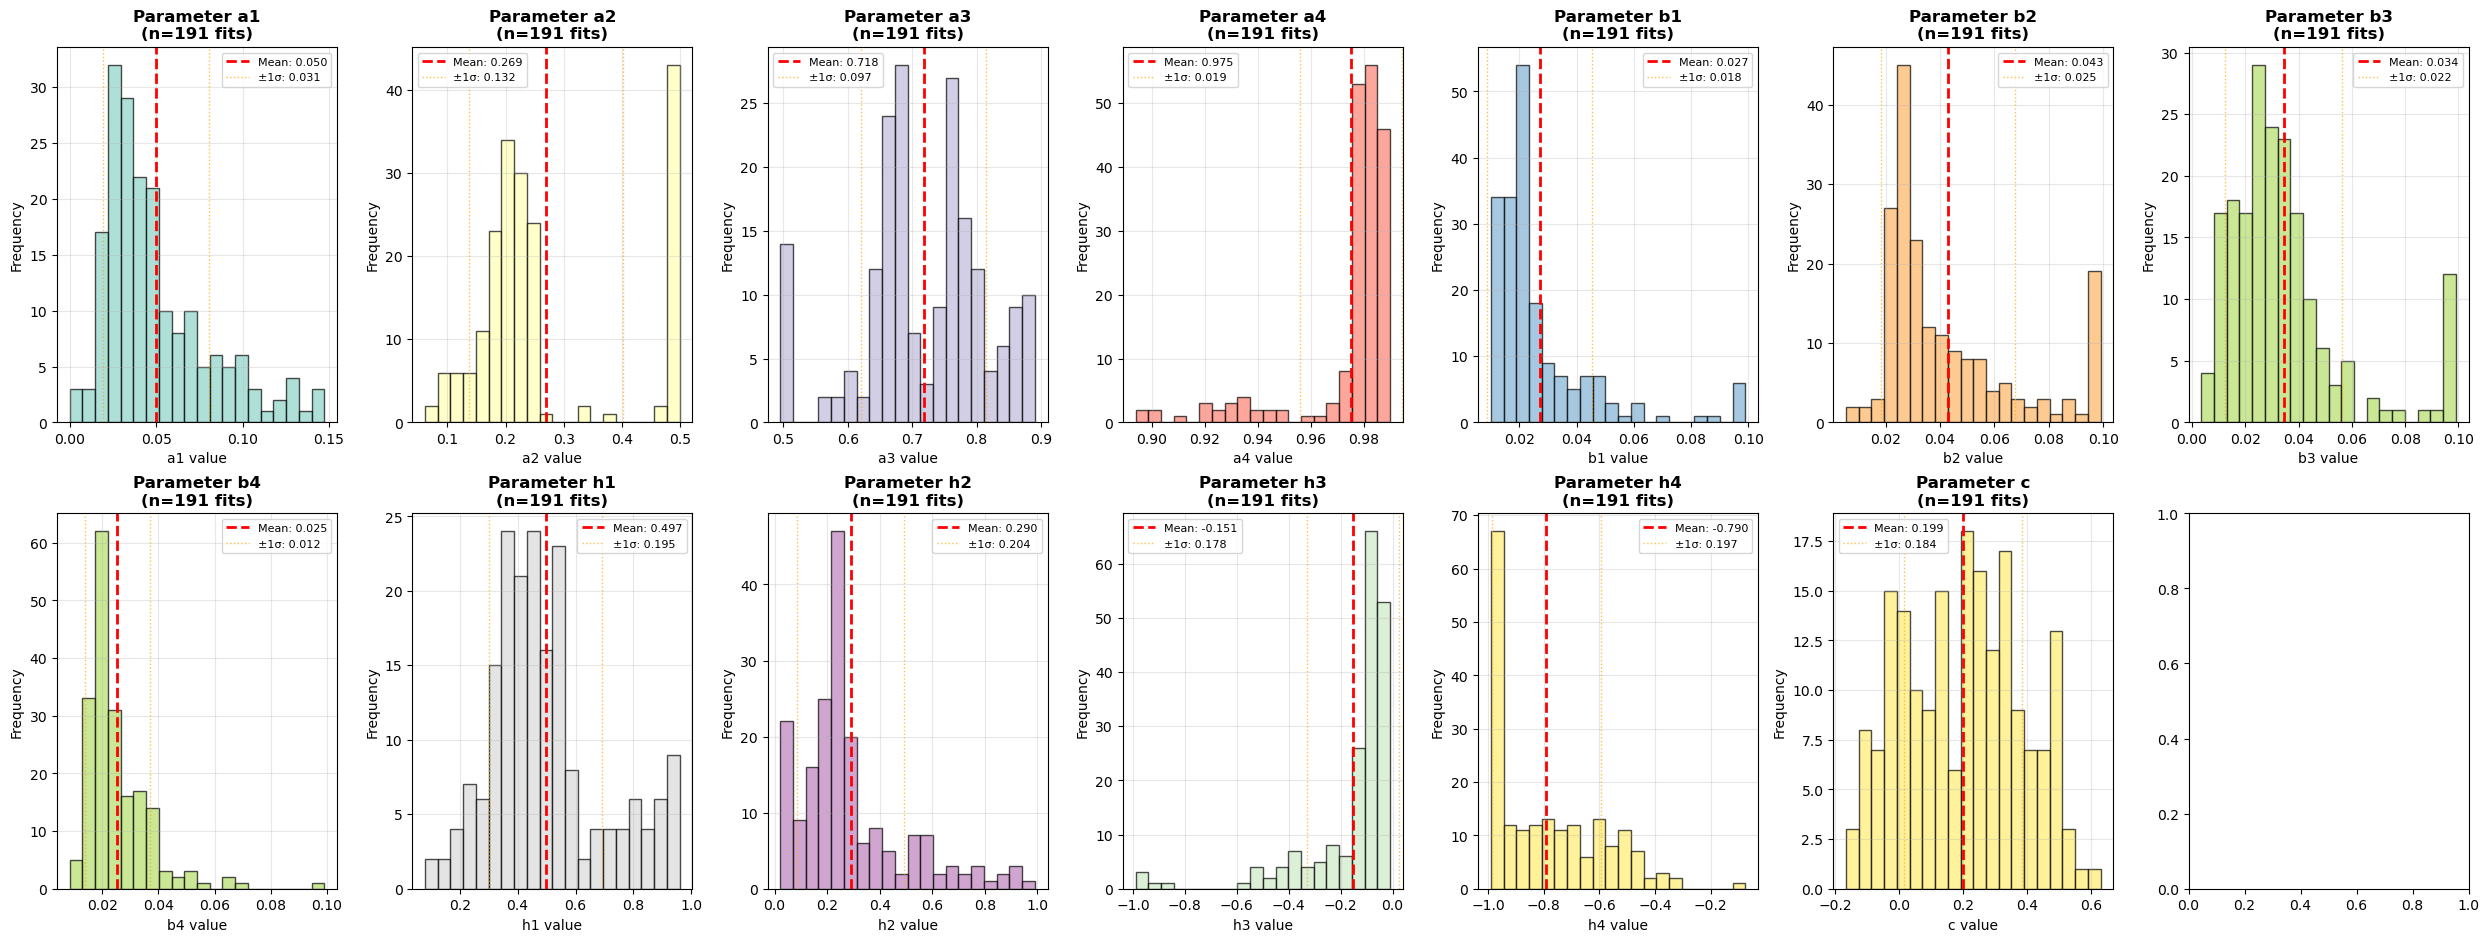


✅ SIGMOID PARAMETER ANALYSIS COMPLETE
🎯 Successfully analyzed 191 sigmoid fits
📈 Overall fitting quality: R² = 0.9942 ± 0.0059


In [33]:
# ===================================================================
# SIGMOID PARAMETER ANALYSIS & STATISTICS
# ===================================================================

def analyze_sigmoid_parameters(sigmoid_results):
    """Analyze the fitted sigmoid parameters across all successful fits"""
    print("📊 SIGMOID PARAMETER ANALYSIS")
    print("=" * 60)
    
    # Collect all successful parameter sets
    all_params = []
    param_names = ['a1', 'a2', 'a3', 'a4', 'b1', 'b2', 'b3', 'b4', 'h1', 'h2', 'h3', 'h4', 'c']
    
    for dataset_name, dataset_data in sigmoid_results['datasets'].items():
        for liquid_name, liquid_data in dataset_data['liquids'].items():
            for cycle_fit in liquid_data['cycles']:
                if cycle_fit['success']:
                    param_dict = {
                        'dataset': dataset_name,
                        'liquid': liquid_name,
                        'cycle': cycle_fit['cycle_number'],
                        'r_squared': cycle_fit['r_squared']
                    }
                    
                    # Add parameter values
                    for i, param_name in enumerate(param_names):
                        param_dict[param_name] = cycle_fit['fitted_params'][i]
                        param_dict[f'{param_name}_error'] = cycle_fit['param_errors'][i] if not np.isnan(cycle_fit['param_errors'][i]) else 0
                    
                    all_params.append(param_dict)
    
    if not all_params:
        print("❌ No successful parameter fits to analyze")
        return None
    
    # Convert to DataFrame for analysis
    params_df = pd.DataFrame(all_params)
    
    print(f"📈 Analyzing {len(params_df)} successful sigmoid fits")
    print(f"   Datasets: {params_df['dataset'].nunique()}")
    print(f"   Liquids: {params_df['liquid'].nunique()}")
    print(f"   Average R²: {params_df['r_squared'].mean():.4f} ± {params_df['r_squared'].std():.4f}")
    
    # Parameter statistics
    print(f"\n📊 PARAMETER STATISTICS:")
    print("-" * 60)
    
    param_stats = {}
    for param in param_names:
        if param in params_df.columns:
            values = params_df[param].values
            valid_values = values[~np.isnan(values)]
            
            if len(valid_values) > 0:
                param_stats[param] = {
                    'mean': np.mean(valid_values),
                    'std': np.std(valid_values),
                    'min': np.min(valid_values),
                    'max': np.max(valid_values),
                    'median': np.median(valid_values)
                }
                
                print(f"{param:>2}: {param_stats[param]['mean']:8.3f} ± {param_stats[param]['std']:6.3f} "
                      f"[{param_stats[param]['min']:8.3f}, {param_stats[param]['max']:8.3f}] "
                      f"(median: {param_stats[param]['median']:7.3f})")
    
    # R² distribution by dataset and liquid
    print(f"\n🎯 R² DISTRIBUTION BY DATASET:")
    print("-" * 40)
    for dataset in params_df['dataset'].unique():
        dataset_data = params_df[params_df['dataset'] == dataset]
        avg_r2 = dataset_data['r_squared'].mean()
        std_r2 = dataset_data['r_squared'].std()
        count = len(dataset_data)
        print(f"{dataset:>15}: {avg_r2:.4f} ± {std_r2:.4f} ({count} fits)")
    
    print(f"\n🧪 R² DISTRIBUTION BY LIQUID:")
    print("-" * 40)
    for liquid in params_df['liquid'].unique():
        liquid_data = params_df[params_df['liquid'] == liquid]
        avg_r2 = liquid_data['r_squared'].mean()
        std_r2 = liquid_data['r_squared'].std()
        count = len(liquid_data)
        
        # Get viscosity info
        liquid_col = f"{liquid}_flow_ml_min"
        viscosity = LIQUIDS_INFO.get(liquid_col, {}).get('viscosity', 'Unknown')
        print(f"{liquid:>8} ({viscosity:>8}): {avg_r2:.4f} ± {std_r2:.4f} ({count} fits)")
    
    return {
        'params_df': params_df,
        'param_stats': param_stats,
        'summary': {
            'total_successful_fits': len(params_df),
            'avg_r_squared': params_df['r_squared'].mean(),
            'std_r_squared': params_df['r_squared'].std(),
            'datasets_analyzed': params_df['dataset'].nunique(),
            'liquids_analyzed': params_df['liquid'].nunique()
        }
    }

def create_parameter_distribution_plots(param_analysis):
    """Create parameter distribution visualization"""
    if param_analysis is None:
        return None
    
    params_df = param_analysis['params_df']
    param_names = ['a1', 'a2', 'a3', 'a4', 'b1', 'b2', 'b3', 'b4', 'h1', 'h2', 'h3', 'h4', 'c']
    
    # Create subplot grid for parameter distributions (2x7 for 14 parameters)
    fig, axes = plt.subplots(2, 7, figsize=(25, 10))
    axes = axes.flatten()
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(param_names)))
    
    for i, param in enumerate(param_names):
        ax = axes[i]
        
        if param in params_df.columns:
            values = params_df[param].values
            valid_values = values[~np.isnan(values)]
            
            if len(valid_values) > 0:
                # Histogram
                ax.hist(valid_values, bins=min(20, len(valid_values)//2), 
                       alpha=0.7, color=colors[i], edgecolor='black')
                
                # Statistics
                mean_val = np.mean(valid_values)
                std_val = np.std(valid_values)
                
                ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                          label=f'Mean: {mean_val:.3f}')
                ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1, alpha=0.7)
                ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1, alpha=0.7,
                          label=f'±1σ: {std_val:.3f}')
                
                ax.set_title(f'Parameter {param}\n(n={len(valid_values)} fits)', fontsize=12, fontweight='bold')
                ax.set_xlabel(f'{param} value', fontsize=10)
                ax.set_ylabel('Frequency', fontsize=10)
                ax.legend(fontsize=8)
                ax.grid(True, alpha=0.3)
        
        else:
            ax.text(0.5, 0.5, f'No data for\nparameter {param}', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12, color='gray')
            ax.set_title(f'Parameter {param}', fontsize=12)
    
    #plt.suptitle('Sigmoid Parameter Distributions Across All Successful Fits', 
    #             fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    
    return fig

# Analyze sigmoid parameters and create visualizations
parameter_analysis = analyze_sigmoid_parameters(sigmoid_fitting_results)

if parameter_analysis:
    print("\n🎨 Creating parameter distribution plots...")
    param_dist_figure = create_parameter_distribution_plots(parameter_analysis)
    if param_dist_figure:
        plt.show()
    
    print(f"\n✅ SIGMOID PARAMETER ANALYSIS COMPLETE")
    print(f"🎯 Successfully analyzed {parameter_analysis['summary']['total_successful_fits']} sigmoid fits")
    print(f"📈 Overall fitting quality: R² = {parameter_analysis['summary']['avg_r_squared']:.4f} ± {parameter_analysis['summary']['std_r_squared']:.4f}")
else:
    print("❌ No successful sigmoid fits available for parameter analysis")

In [34]:
# ===================================================================
# SAVE COMPREHENSIVE CYCLE DATASET TO CSV
# ===================================================================

import os

# Create Data directory if it doesn't exist
data_dir = "Data"
os.makedirs(data_dir, exist_ok=True)

# Save the comprehensive cycle dataset as CSV
csv_filename = "sigmoid_cycles.csv"
csv_filepath = os.path.join(data_dir, csv_filename)

comprehensive_cycle_dataset.to_csv(csv_filepath, index=False)

print("💾 DATASET EXPORT COMPLETE")
print("=" * 50)
print(f"📄 File saved: {csv_filepath}")
print(f"📊 Dataset shape: {comprehensive_cycle_dataset.shape}")
print(f"🎯 Total cycles exported: {len(comprehensive_cycle_dataset)}")
print(f"📈 Columns exported: {len(comprehensive_cycle_dataset.columns)}")
print(f"✅ CSV file ready for machine learning applications!")

💾 DATASET EXPORT COMPLETE
📄 File saved: Data\sigmoid_cycles.csv
📊 Dataset shape: (191, 19)
🎯 Total cycles exported: 191
📈 Columns exported: 19
✅ CSV file ready for machine learning applications!
